<a href="https://colab.research.google.com/github/ArrenOnom/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/blob/main/Eritrea_Precipitation_Dynamics_CMIP6_Evaluation_1981_2100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =================================================================
# PROJECT: NEX-GDDP-CMIP6 Rainfall Projections - Eritrea
# AUTHORS: Tesfalem W. Ghebretnsae, Elsayed S. Mohamed, Umar Joseph James
# DESCRIPTION: Master Setup & Data Path Configuration
# =================================================================

import os
import subprocess
import pandas as pd
import geopandas as gpd
import rasterio

# --- 1. REPOSITORY CONFIGURATION ---
REPO_URL = "https://github.com/ArrenOnom/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections.git"
REPO_NAME = "NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections"
BASE_PATH = f"/content/{REPO_NAME}"

# --- 2. CLONE REPOSITORY ---
if not os.path.exists(BASE_PATH):
    print(f"Cloning {REPO_NAME} from GitHub...")
    subprocess.run(["git", "clone", REPO_URL])
else:
    print("Repository already exists. Pulling latest updates...")
    %cd {BASE_PATH}
    !git pull
    %cd ..

# --- 3. DYNAMIC PATH MAPPING (Concise Constants) ---

# AEZ Level Raw Data (CSVs)
AEZ_DIR = f"{BASE_PATH}/data/AEZ"
CSV_ARID = f"{AEZ_DIR}/CMIP6_34Models_Verified_Arid_Lowland.csv"
CSV_HIGHLAND = f"{AEZ_DIR}/CMIP6_34Models_Verified_Moist_Highland.csv"
CSV_LOWLAND = f"{AEZ_DIR}/CMIP6_34Models_Verified_Moist_Lowland.csv"

# National & Top 10 Raw Data
NAT_CSV = f"{BASE_PATH}/data/rainfall_csv/CMIP6_34Models_Verified_Rainfall.csv"
TOP_DIR = f"{BASE_PATH}/data/top_models"
TOP_SSP245 = f"{TOP_DIR}/CMIP6_Eritrea_NEW_Top10_Future_SSP245_2015_2100.csv"
TOP_SSP585 = f"{TOP_DIR}/CMIP6_Eritrea_NEW_Top10_Future_SSP585_2015_2100.csv"
TOP_HIST = f"{TOP_DIR}/CMIP6_Eritrea_NEW_Top10_Historical_1981_2014.csv"

# Spatial Data (Shapefiles)
SHP_PATH = f"{BASE_PATH}/shp/SELECTED_ZONES_WGS1984.shp"

# GeoTIFF Maps
HIST_MAPS_DIR = f"{BASE_PATH}/geotiff/individual_models"
ENSEMBLE_DIR = f"{BASE_PATH}/geotiff/ensembles"

# Output Directory (For saving charts/results)
OUTPUT_DIR = f"{BASE_PATH}/outputs"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- 4. VERIFICATION CHECK ---
print("-" * 30)
print(f"✅ SETUP COMPLETE")
print(f"Directory: {BASE_PATH}")
print(f"Individual Model Tiffs Found: {len([f for f in os.listdir(HIST_MAPS_DIR) if f.endswith('.tif')])}")
print(f"Ensemble Tiffs Found: {len([f for f in os.listdir(ENSEMBLE_DIR) if f.endswith('.tif')])}")
print("-" * 30)

Cloning NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections from GitHub...
------------------------------
✅ SETUP COMPLETE
Directory: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections
Individual Model Tiffs Found: 35
Ensemble Tiffs Found: 5
------------------------------


In [2]:
# =================================================================
# SCRIPT 1: AEZ ZONAL LEVEL ANALYSIS (Historical)
# =================================================================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import os

# 1. SETUP - Using the paths defined in our Master First Page
# We create a specific sub-folder in outputs for this script
zonal_output = f"{OUTPUT_DIR}/ZONAL_ANALYSIS_A"
if not os.path.exists(zonal_output):
    os.makedirs(zonal_output)

# Mapping the exact filenames we uploaded to GitHub
zones = {
    'Arid_Lowland': CSV_ARID,
    'Moist_Highland': CSV_HIGHLAND,
    'Moist_Lowland': CSV_LOWLAND
}

# 2. THE METRICS ENGINE
def calculate_perfect_metrics(obs, sim):
    mean_o, mean_s = np.mean(obs), np.mean(sim)
    std_o, std_s = np.std(obs), np.std(sim)

    # Statistical Metrics
    r, _ = pearsonr(obs, sim)
    nsd = std_s / std_o
    crmsd = np.sqrt(np.mean(((sim - mean_s) - (obs - mean_o))**2))
    rmse = np.sqrt(np.mean((sim - obs)**2))
    mb = mean_s - mean_o
    nrmse = rmse / (np.max(obs) - np.min(obs)) if (np.max(obs) - np.min(obs)) != 0 else 0

    # TSS (Taylor Skill Score): Exact as per PhD methodology
    tss = (4 * (1 + r)) / ((nsd + (1/nsd))**2 * (1 + 1.0))

    # IVS (Interannual Variability Skill Score)
    ivs = (nsd - 1)**2

    return [r, nsd, crmsd, rmse, mb, nrmse, tss, ivs]

# 3. EXECUTION LOOP
for zone_name, file_path in zones.items():
    if not os.path.exists(file_path):
        print(f"⚠️ Warning: {file_path} not found. Skipping {zone_name}.")
        continue

    # Load and clean data
    df = pd.read_csv(file_path).dropna(subset=['Precip_mm'])

    # Ensure standard column naming and group by Model
    df_avg = df.groupby(['Model', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

    # Extract Observation (CHIRPS)
    obs_df = df_avg[df_avg['Model'] == 'CHIRPS'].sort_values(['Year', 'Month'])

    results = []
    # Loop through all 34 Models
    for m in sorted([x for x in df_avg['Model'].unique() if x != 'CHIRPS']):
        sim_df = df_avg[df_avg['Model'] == m].sort_values(['Year', 'Month'])

        # Syncing observation and simulation periods
        merged = pd.merge(obs_df, sim_df, on=['Year', 'Month'], suffixes=('_o', '_s'))

        if not merged.empty:
            metrics = calculate_perfect_metrics(merged['Precip_mm_o'].values, merged['Precip_mm_s'].values)
            results.append([m] + metrics)

    # Create Metrics Table
    columns = ['Model', 'r', 'NSD', 'CRMSD', 'RMSE', 'MB', 'NRMSE', 'TSS', 'IVS']
    perf_df = pd.DataFrame(results, columns=columns)
    perf_df.to_csv(f"{zonal_output}/Table1_Metrics_{zone_name}.csv", index=False)

    # 4. CRI RANKING (Comprehensive Ranking Index)
    s = perf_df.copy()

    # Normalization Logic (Higher is better for R and TSS, lower is better for others)
    s['s_r'] = (s['r']-s['r'].min())/(s['r'].max()-s['r'].min())
    s['s_tss'] = (s['TSS']-s['TSS'].min())/(s['TSS'].max()-s['TSS'].min())
    s['s_nsd'] = 1 - abs(1-s['NSD'])/abs(1-s['NSD']).max()
    s['s_mb'] = 1 - (abs(s['MB'])-abs(s['MB']).min())/(abs(s['MB']).max()-abs(s['MB']).min())

    for c in ['CRMSD', 'RMSE', 'NRMSE', 'IVS']:
        s[f's_{c.lower()}'] = 1 - (s[c]-s[c].min())/(s[c].max()-s[c].min())

    # Calculate Mean CRI Score
    rank_cols = ['s_r','s_tss','s_nsd','s_mb','s_crmsd','s_rmse','s_nrmse','s_ivs']
    rank_df = pd.DataFrame({
        'Model': s['Model'],
        'CRI': s[rank_cols].mean(axis=1)
    })

    rank_df = rank_df.sort_values('CRI', ascending=False).reset_index(drop=True)
    rank_df['Rank'] = rank_df.index + 1

    # Save the Final Ranking Table
    rank_df.to_csv(f"{zonal_output}/Table2_CRI_{zone_name}.csv", index=False)

print(f"✅ Zonal Outputs Finalized in: {zonal_output}")

✅ Zonal Outputs Finalized in: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/ZONAL_ANALYSIS_A


In [3]:
# =================================================================
# SCRIPT 2: NATIONAL LEVEL ANALYSIS (Historical)
# =================================================================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import os

# 1. SETUP - Using the paths defined in our Master First Page
# Input from GitHub: data/rainfall_csv/CMIP6_34Models_Verified_Rainfall.csv
input_file = NAT_CSV

# Output to GitHub-synced folder
national_output = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A"
if not os.path.exists(national_output):
    os.makedirs(national_output)

# 2. THE METRICS ENGINE
def calculate_perfect_metrics(obs, sim):
    mean_o, mean_s = np.mean(obs), np.mean(sim)
    std_o, std_s = np.std(obs), np.std(sim)

    # 1. Pearson Correlation (r)
    r, _ = pearsonr(obs, sim)

    # 2. Normalized Standard Deviation (NSD)
    nsd = std_s / std_o

    # 3. Centered Root Mean Square Difference (CRMSD)
    crmsd = np.sqrt(np.mean(((sim - mean_s) - (obs - mean_o))**2))

    # 4. Root Mean Square Error (RMSE)
    rmse = np.sqrt(np.mean((sim - obs)**2))

    # 5. Mean Bias (MB)
    mb = mean_s - mean_o

    # 6. Normalized RMSE (NRMSE)
    nrmse = rmse / (np.max(obs) - np.min(obs)) if (np.max(obs) - np.min(obs)) != 0 else 0

    # 7. Taylor Skill Score (TSS)
    tss = (4 * (1 + r)) / ((nsd + (1/nsd))**2 * (1 + 1.0))

    # 8. Interannual Variability Score (IVS)
    ivs = (nsd - 1)**2

    return [r, nsd, crmsd, rmse, mb, nrmse, tss, ivs]

# 3. DATA PROCESSING
if not os.path.exists(input_file):
    print(f"❌ Error: National input file not found at {input_file}")
else:
    print(f"Loading National Data from {input_file}...")
    df = pd.read_csv(input_file).dropna(subset=['Precip_mm'])

    # Grouping to get spatial average depth (National Mean)
    df_avg = df.groupby(['Model', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

    obs_series = df_avg[df_avg['Model'] == 'CHIRPS'].sort_values(['Year', 'Month'])
    models = sorted([m for m in df_avg['Model'].unique() if m != 'CHIRPS'])

    print(f"Processing {len(models)} models at National scale...")
    results = []
    for m in models:
        sim_series = df_avg[df_avg['Model'] == m].sort_values(['Year', 'Month'])
        merged = pd.merge(obs_series, sim_series, on=['Year', 'Month'], suffixes=('_o', '_s'))

        if len(merged) > 1:
            res = calculate_perfect_metrics(merged['Precip_mm_o'].values, merged['Precip_mm_s'].values)
            results.append([m] + res)

    # 4. SAVE TABLE 1: PERFORMANCE METRICS
    perf_df = pd.DataFrame(results, columns=['Model', 'r', 'NSD', 'CRMSD', 'RMSE', 'MB', 'NRMSE', 'TSS', 'IVS'])
    perf_df.to_csv(f'{national_output}/National_Table1_Metrics.csv', index=False)

    # 5. SAVE TABLE 2: CRI RANKING
    s = perf_df.copy()

    # Normalization (0 to 1 scaling)
    s['s_r'] = (s['r'] - s['r'].min()) / (s['r'].max() - s['r'].min())
    s['s_tss'] = (s['TSS'] - s['TSS'].min()) / (s['TSS'].max() - s['TSS'].min())
    s['s_nsd'] = 1 - abs(1 - s['NSD']) / abs(1 - s['NSD']).max()
    s['s_mb'] = 1 - (abs(s['MB']) - abs(s['MB']).min()) / (abs(s['MB']).max() - abs(s['MB']).min())

    for col in ['CRMSD', 'RMSE', 'NRMSE', 'IVS']:
        s[f's_{col.lower()}'] = 1 - (s[col] - s[col].min()) / (s[col].max() - s[col].min())

    # Final CRI calculation
    rank_cols = ['s_r','s_tss','s_nsd','s_mb','s_crmsd','s_rmse','s_nrmse','s_ivs']
    rank_df = pd.DataFrame({
        'Model': s['Model'],
        'CRI': s[rank_cols].mean(axis=1)
    })

    rank_df = rank_df.sort_values('CRI', ascending=False).reset_index(drop=True)
    rank_df['Rank'] = rank_df.index + 1

    rank_df.to_csv(f'{national_output}/National_Table2_CRI.csv', index=False)

    print(f"✅ National Evaluation Complete. All files saved in: {national_output}")

Loading National Data from /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/data/rainfall_csv/CMIP6_34Models_Verified_Rainfall.csv...
Processing 34 models at National scale...
✅ National Evaluation Complete. All files saved in: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/NATIONAL_ANALYSIS_A


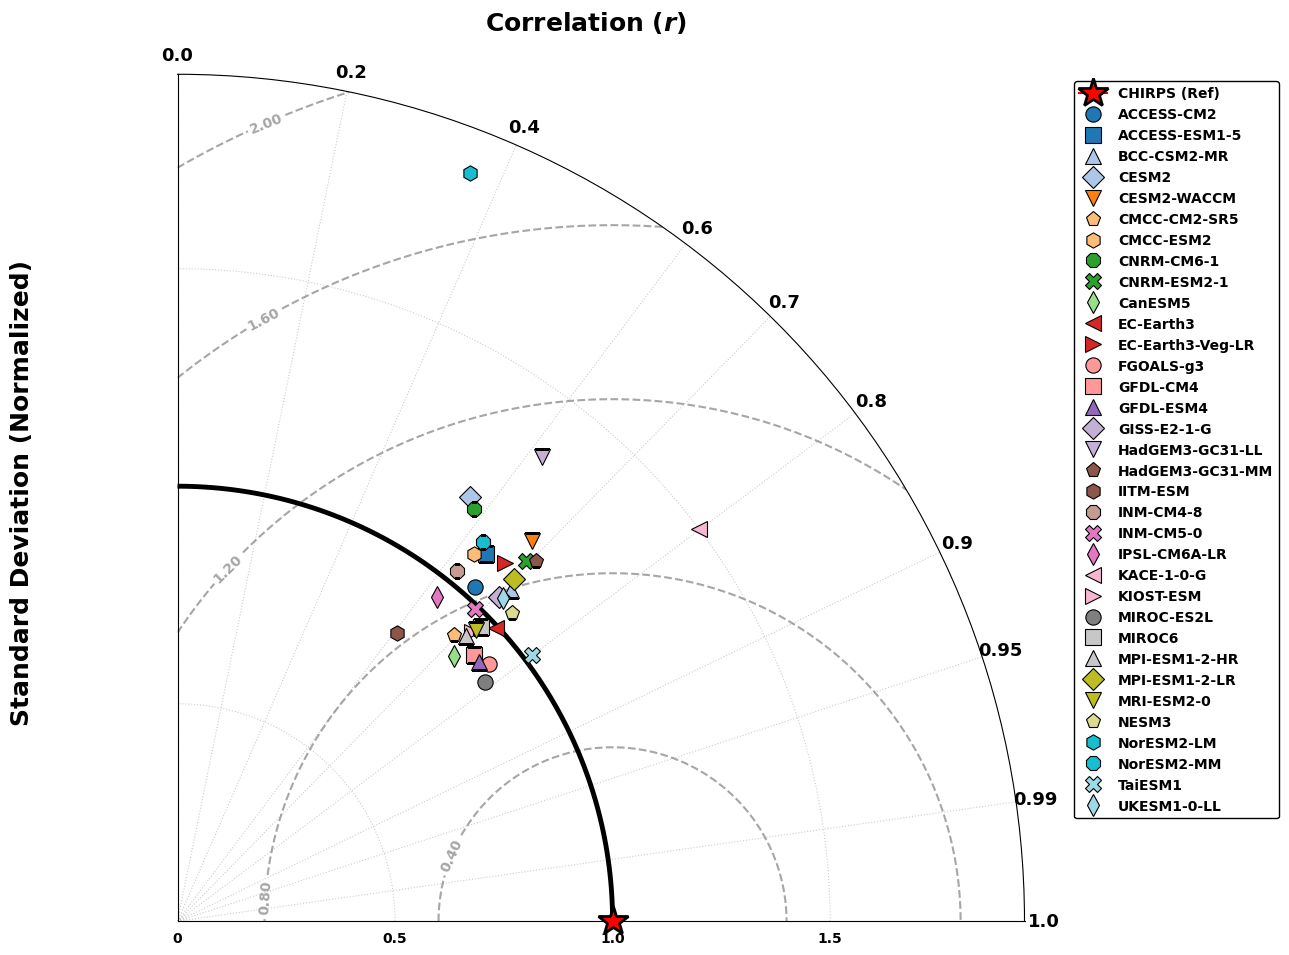

📊 Taylor Diagram saved to: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/NATIONAL_ANALYSIS_A/National_Taylor_Final_A.png


In [4]:
# =================================================================
# SCRIPT 3: TAYLOR DIAGRAM VISUALIZATION (National Level)
# =================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP - Linking to the output of Script 2
# Input comes from the folder created in the previous step
input_folder = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A"
output_folder = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A"

def plot_national_taylor_final(df, output_path):
    # Global Bold Settings for Academic Quality
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    fig = plt.figure(figsize=(12, 11), facecolor='white')
    ax = fig.add_subplot(111, projection='polar')

    # First Quadrant Only (Standard for Rainfall Correlation)
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    # Correlation Axis (theta / angular coordinate)
    r_ticks = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    ax.set_xticks(np.arccos(r_ticks))
    ax.set_xticklabels([str(r) for r in r_ticks], fontweight='bold', fontsize=13)

    # Standard Deviation Axis (radial coordinate)
    # Normalized so CHIRPS is exactly at 1.0
    std_limit = max(1.5, df['NSD'].max() + 0.1)
    ax.set_ylim(0, std_limit)
    ax.set_yticks([0, 0.5, 1.0, 1.5])
    ax.set_yticklabels(['0', '0.5', '1.0', '1.5'], fontweight='bold', fontsize=13)

    ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # CHIRPS Reference Point & Reference Arc
    # Plotting a thick arc at NSD=1.0 to show the 'Perfect' match line
    ax.plot(np.linspace(0, np.pi/2, 100), np.ones(100), color='black', lw=3.5, zorder=4)
    ax.plot(0, 1.0, marker='*', color='red', ms=22, label='CHIRPS (Ref)',
            mec='black', mew=2.0, clip_on=False, zorder=7)

    # Plot Models with Distinct Markers and Colors
    N = len(df)
    cmap = plt.get_cmap('tab20', N)
    markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8', 'X', 'd', '<', '>']

    for i, row in df.iterrows():
        ax.plot(np.arccos(row['r']), row['NSD'], marker=markers[i % len(markers)],
                ls='', ms=11, label=row['Model'], mfc=cmap(i), mec='black', mew=0.8, zorder=6)

    # CRMSD (Centered RMS Difference) Contours
    # These circular dashed lines show how far each model is from the red star
    rs, ts = np.meshgrid(np.linspace(0, std_limit, 100), np.linspace(0, np.pi/2, 100))
    rmsd = np.sqrt(1 + rs**2 - 2 * rs * np.cos(ts))
    contours = ax.contour(ts, rs, rmsd, levels=5, colors='gray', linestyles='--', alpha=0.7)
    ax.clabel(contours, inline=1, fontsize=10, fmt='%.2f')

    # Legend Configuration
    leg = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10,
                    frameon=True, edgecolor='black', framealpha=1)
    for text in leg.get_texts(): text.set_fontweight('bold')

    # --- AXIS LABELS ---
    fig.text(0.5, 0.92, 'Correlation ($r$)', ha='center', fontsize=18, fontweight='bold')
    fig.text(0.02, 0.5, 'Standard Deviation (Normalized)', va='center', rotation='vertical', fontsize=18, fontweight='bold')

    # Save at high DPI for Journal Publication
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    plt.show()
    print(f"📊 Taylor Diagram saved to: {output_path}")

# Run Execution
file_path = os.path.join(input_folder, "National_Table1_Metrics.csv")
if os.path.exists(file_path):
    df_metrics = pd.read_csv(file_path)
    output_img = os.path.join(output_folder, "National_Taylor_Final_A.png")
    plot_national_taylor_final(df_metrics, output_img)
else:
    print(f"❌ Error: Could not find {file_path}. Please run Script 2 first.")

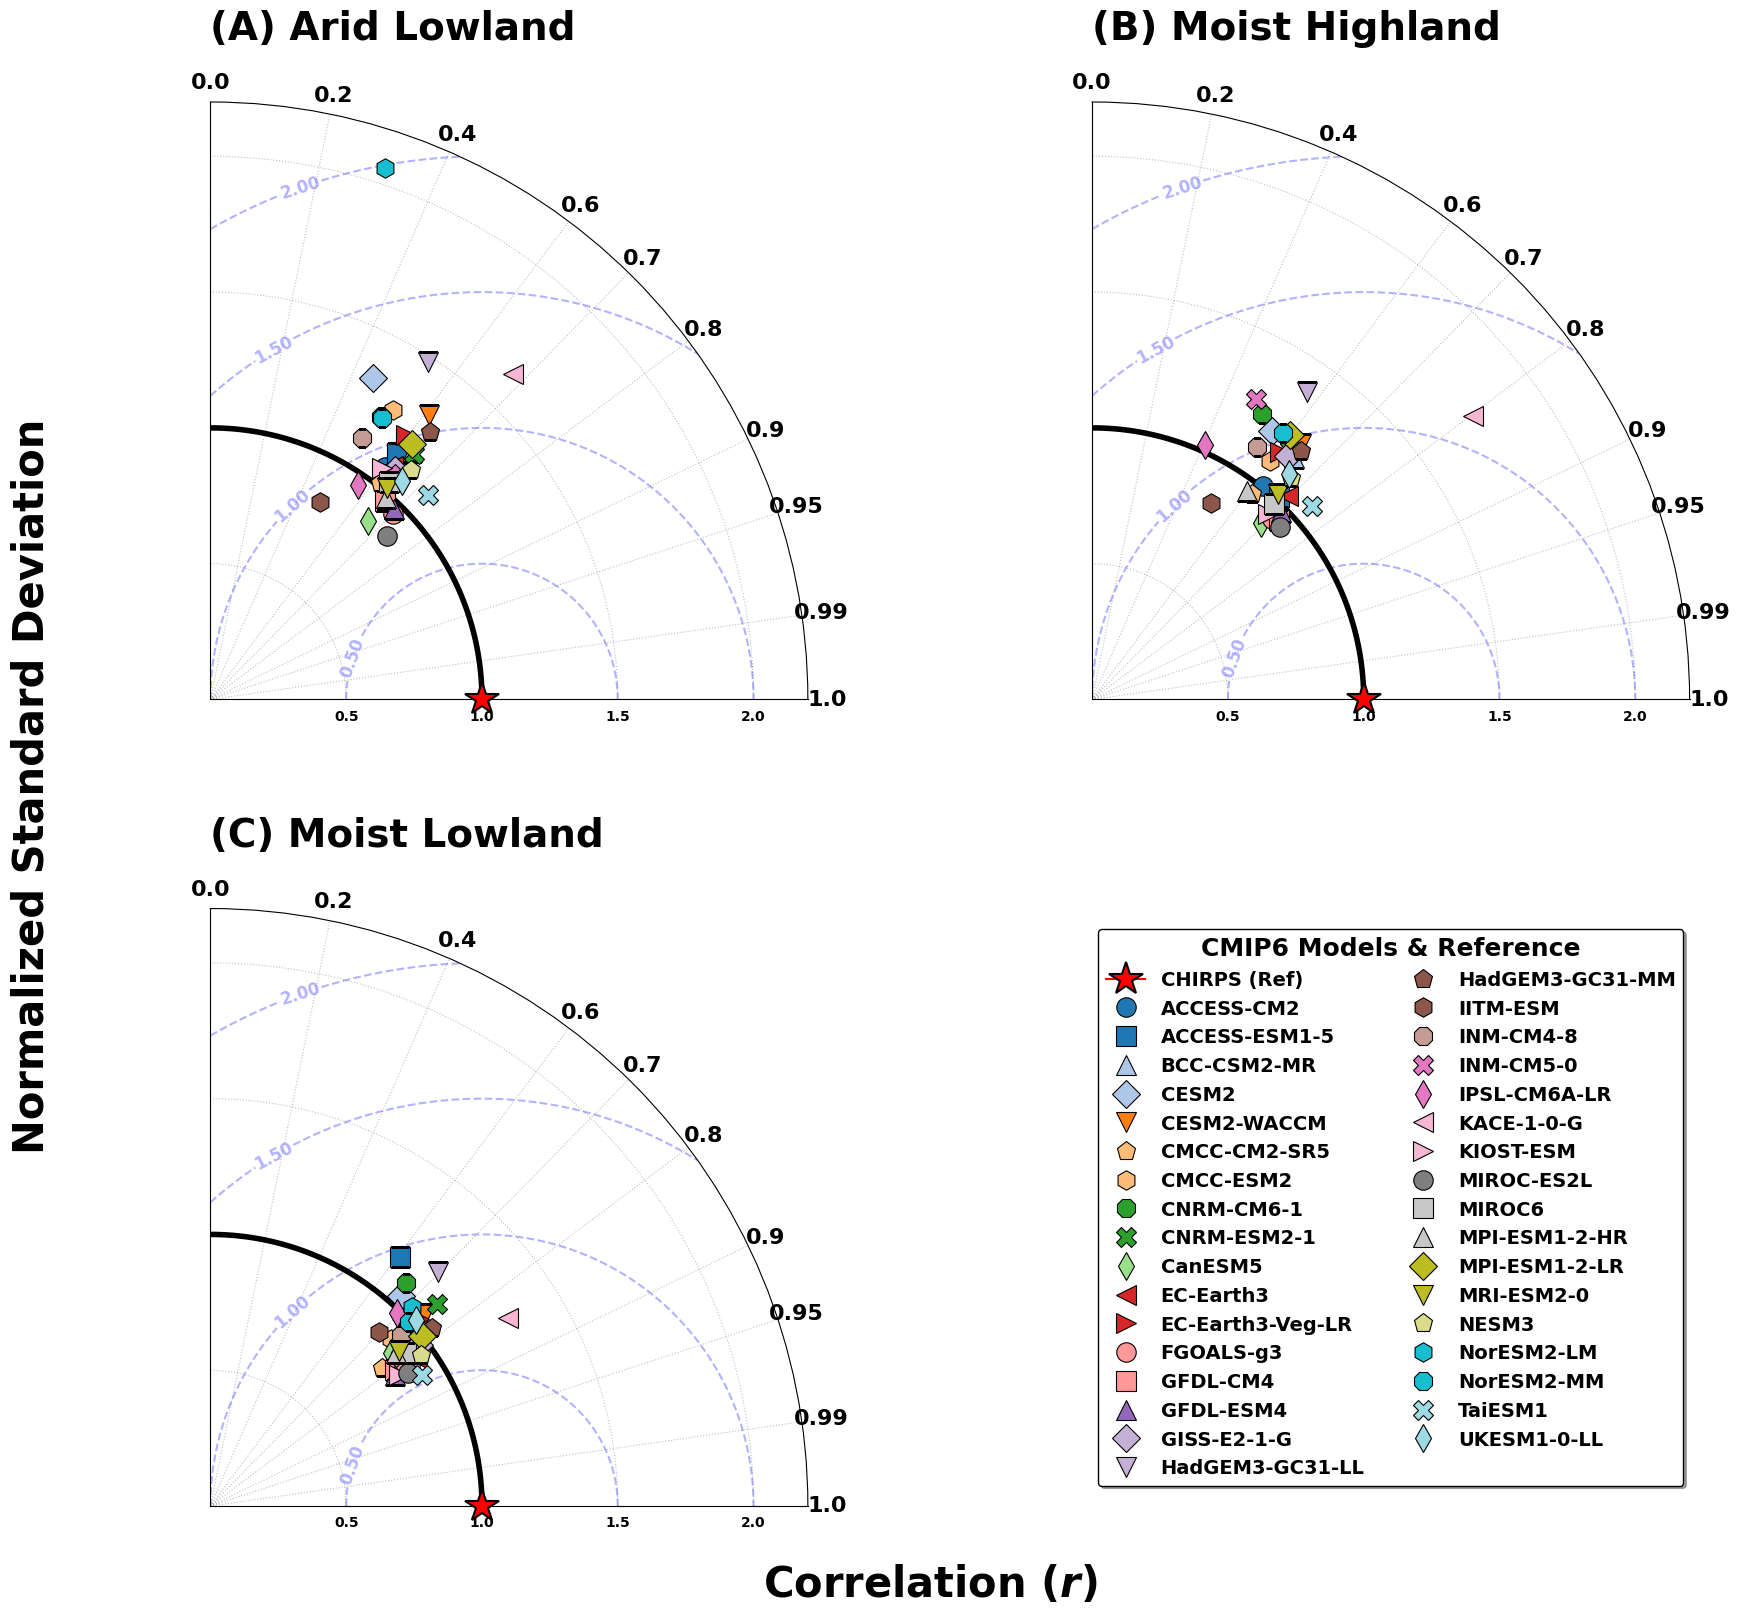

📊 2x2 Taylor Grid saved to: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/ZONAL_ANALYSIS_A/Figure3_2x2_Taylor.png


In [5]:
# =================================================================
# SCRIPT 4: MULTI-PANEL TAYLOR DIAGRAM (AEZ Level)
# =================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP - Linking to the output of Script 1
# Input comes from the Zonal Analysis folder
input_folder = f"{OUTPUT_DIR}/ZONAL_ANALYSIS_A"
output_folder = f"{OUTPUT_DIR}/ZONAL_ANALYSIS_A"

# Mapping files to Panels (Grid positions A, B, and C)
zones_list = [
    ('Arid_Lowland', 'A'),
    ('Moist_Highland', 'B'),
    ('Moist_Lowland', 'C')
]

def generate_grid_taylor(input_folder, output_path):
    # Academic Font Settings
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    # Large canvas for the 2x2 grid (leaving the 4th slot for the legend)
    fig = plt.figure(figsize=(20, 18), facecolor='white')

    # Storage for unified legend across all panels
    all_handles = []
    all_labels = []

    for idx, (zone, label) in enumerate(zones_list):
        file_path = os.path.join(input_folder, f"Table1_Metrics_{zone}.csv")
        if not os.path.exists(file_path):
            print(f"⚠️ Warning: {file_path} not found. Skipping...")
            continue

        df = pd.read_csv(file_path)

        # Create subplot in positions 1, 2, or 3
        ax = fig.add_subplot(2, 2, idx + 1, projection='polar')

        # First Quadrant Setup
        ax.set_thetamin(0)
        ax.set_thetamax(90)

        # Correlation Axis (Angular)
        r_ticks = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
        ax.set_xticks(np.arccos(r_ticks))
        ax.set_xticklabels([str(r) for r in r_ticks], fontweight='bold', fontsize=16)

        # Radial Axis (Normalized Standard Deviation)
        std_limit = 2.2
        ax.set_ylim(0, std_limit)
        ax.set_yticks([0.5, 1.0, 1.5, 2.0])
        ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'], fontweight='bold', fontsize=16)
        ax.grid(True, linestyle=':', alpha=0.5, color='gray')

        # CHIRPS Reference Arc and Star
        ref_line, = ax.plot(np.linspace(0, np.pi/2, 100), np.ones(100), color='black', lw=4, zorder=4)
        ref_star, = ax.plot(0, 1.0, marker='*', color='red', ms=25, label='CHIRPS (Ref)',
                            mec='black', mew=1.5, clip_on=False, zorder=10)

        # Plot 34 Models with consistent markers
        N = len(df)
        cmap = plt.get_cmap('tab20', N)
        markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8', 'X', 'd', '<', '>']

        for i, row in df.iterrows():
            m_handle, = ax.plot(np.arccos(row['r']), row['NSD'], marker=markers[i % len(markers)],
                               ls='', ms=14, label=row['Model'], mfc=cmap(i), mec='black', mew=0.8, zorder=8)

            # Collect labels from the first zone to build a single shared legend
            if idx == 0:
                all_handles.append(m_handle)
                all_labels.append(row['Model'])

        # Prepend CHIRPS to the shared legend list
        if idx == 0:
            all_handles.insert(0, ref_star)
            all_labels.insert(0, 'CHIRPS (Ref)')

        # CRMSD Blue Contours (RMSE difference from reference)
        rs, ts = np.meshgrid(np.linspace(0, std_limit, 100), np.linspace(0, np.pi/2, 100))
        rmsd = np.sqrt(1 + rs**2 - 2 * rs * np.cos(ts))
        contours = ax.contour(ts, rs, rmsd, levels=4, colors='blue', linestyles='--', alpha=0.3)
        ax.clabel(contours, inline=1, fontsize=12, fmt='%.2f')

        # Sub-panel Title
        ax.set_title(f"({label}) {zone.replace('_', ' ')}", loc='left',
                     fontsize=28, fontweight='bold', pad=45)

    # 2. CREATE UNIFIED LEGEND in the 4th (bottom-right) slot
    leg_ax = fig.add_subplot(2, 2, 4)
    leg_ax.axis('off') # Hide the axes grid

    leg_ax.legend(all_handles, all_labels, loc='center', fontsize=14,
                  ncol=2, frameon=True, edgecolor='black', shadow=True,
                  title="CMIP6 Models & Reference", title_fontsize=18)

    # Global Axis Labels for the 2x2 grid
    fig.text(0.5, 0.05, 'Correlation ($r$)', ha='center', fontsize=30, fontweight='bold')
    fig.text(0.04, 0.5, 'Normalized Standard Deviation', va='center', rotation='vertical',
             fontsize=30, fontweight='bold')

    # Spacing adjustment
    plt.subplots_adjust(wspace=0.3, hspace=0.35, bottom=0.1, left=0.12, right=0.9)

    # Save as high-resolution PNG for thesis inclusion
    plt.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"📊 2x2 Taylor Grid saved to: {output_path}")

# Run Execution
output_img = os.path.join(output_folder, "Figure3_2x2_Taylor.png")
generate_grid_taylor(input_folder, output_img)

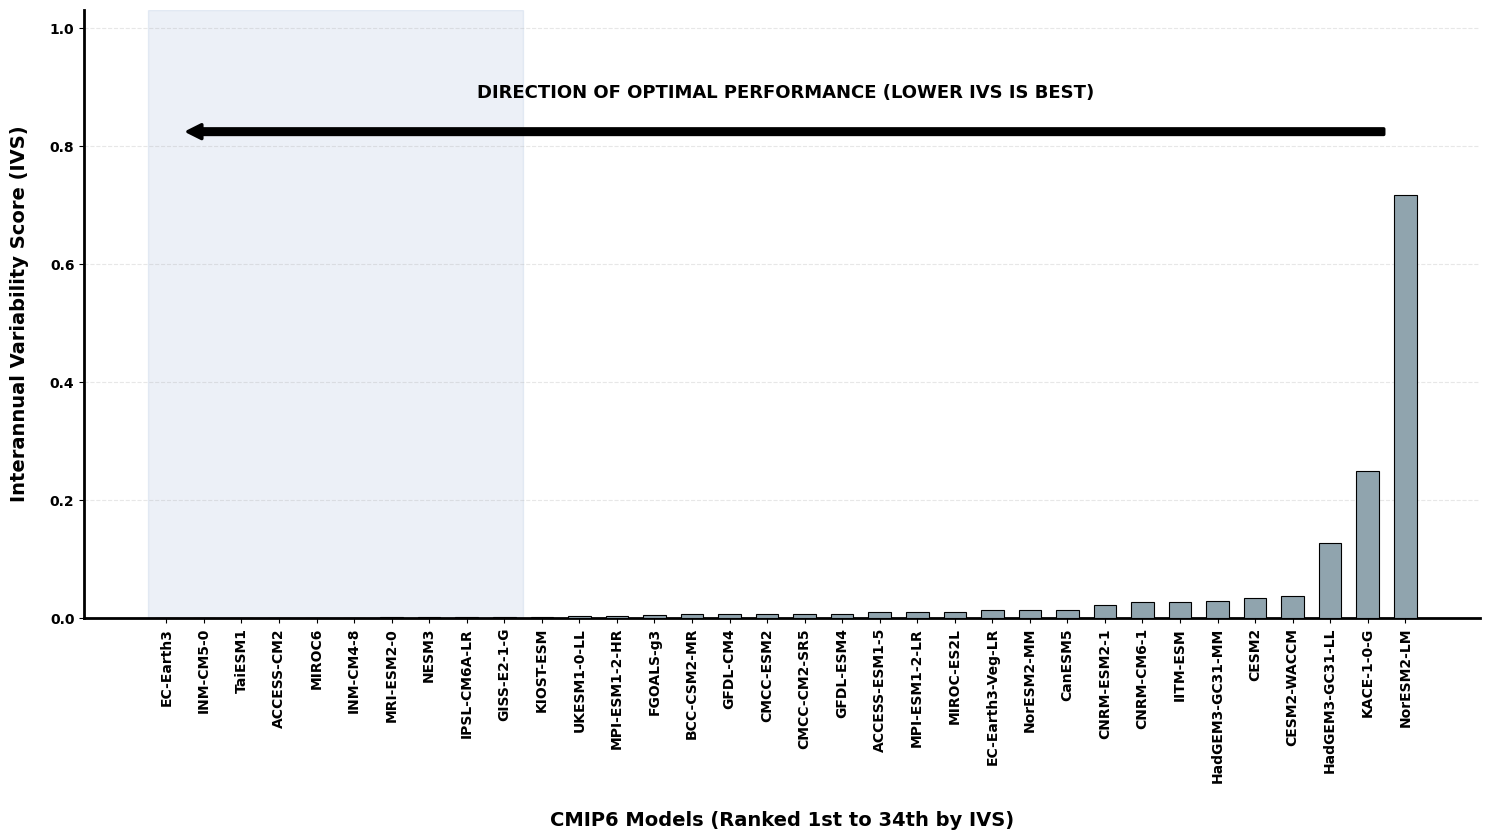

✅ IVS Performance Plot saved to: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/NATIONAL_ANALYSIS_A/National_IVS_Final_Gradient_Arrow.png


In [6]:
# =================================================================
# SCRIPT 5: IVS GRADIENT ANALYSIS & PERFORMANCE DIRECTION
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyArrowPatch

# 1. SETUP - Linking to the National Analysis folder
input_file = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A/National_Table1_Metrics.csv"
output_path = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A/National_IVS_Final_Gradient_Arrow.png"

# Ensure directory exists (though it should from Script 2)
if not os.path.exists(os.path.dirname(output_path)):
    os.makedirs(os.path.dirname(output_path))

# 2. LOAD & SORT
# Lower IVS is better (Closer to 0 means the model matches historical variability)
if not os.path.exists(input_file):
    print(f"❌ Error: {input_file} not found. Please run Script 2 first.")
else:
    df = pd.read_csv(input_file)
    # Sort from best (lowest IVS) to worst (highest IVS)
    df_sorted = df.sort_values('IVS', ascending=True).reset_index(drop=True)

    # 3. CREATE PLOT
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"
    fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')

    # Define Colors: Deep Navy Blue for the "Elite Top 10", Slate Grey for the rest
    colors = ['#0D47A1' if i < 10 else '#90A4AE' for i in range(len(df_sorted))]

    # 4. DRAW BARS
    bars = ax.bar(df_sorted.index, df_sorted['IVS'], color=colors,
                  edgecolor='black', linewidth=0.8, width=0.6, zorder=3)

    # 5. DIRECTIONAL PERFORMANCE ARROW
    # Arrow starts over high-error models and points toward the low-error "Elite" models
    arrow_y_height = df_sorted['IVS'].max() * 1.15
    arrow_start_x = len(df_sorted) - 1.5
    arrow_end_x = 0.5

    arrow = FancyArrowPatch((arrow_start_x, arrow_y_height),
                           (arrow_end_x, arrow_y_height),
                           mutation_scale=20,
                           color='black', lw=2.5, zorder=10)
    ax.add_patch(arrow)

    # 6. PUBLICATION ANNOTATION
    ax.text((arrow_start_x + arrow_end_x)/2, arrow_y_height * 1.06,
            'DIRECTION OF OPTIMAL PERFORMANCE (LOWER IVS IS BEST)',
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', zorder=11)

    # 7. AXIS STYLING
    ax.set_xticks(df_sorted.index)
    ax.set_xticklabels(df_sorted['Model'], rotation=90, fontweight='bold', fontsize=10)

    ax.set_ylabel('Interannual Variability Score (IVS)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_xlabel('CMIP6 Models (Ranked 1st to 34th by IVS)',
                  fontsize=14, fontweight='bold', labelpad=20)

    # Minimalist Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    # Highlight the "Top 10" Zone with a subtle blue shade
    ax.axvspan(-0.5, 9.5, color='#0D47A1', alpha=0.08, zorder=1, label='Top 10 Models')

    # Set Y-axis limits to accommodate the arrow and label
    ax.set_ylim(0, arrow_y_height * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

    # Save and Show
    plt.tight_layout()
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    plt.show()
    print(f"✅ IVS Performance Plot saved to: {output_path}")

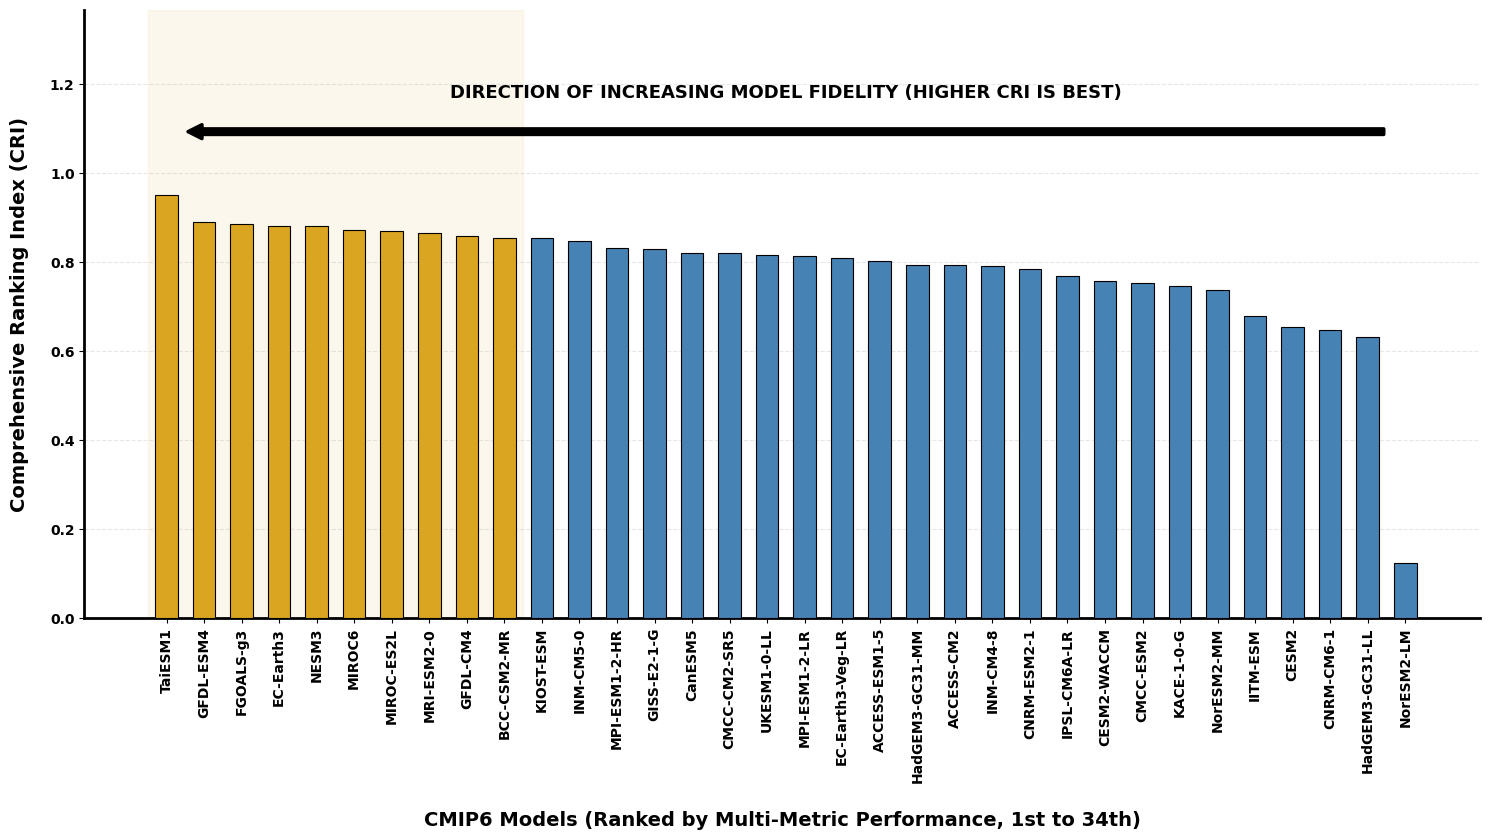

✅ National CRI Skyline Plot saved to: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/NATIONAL_ANALYSIS_A/National_CRI_Final_Skyline_Arrow.png


In [7]:
# =================================================================
# SCRIPT 6: COMPREHENSIVE RANKING INDEX (CRI) SKYLINE ANALYSIS
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyArrowPatch

# 1. SETUP - Linking to the National CRI table from Script 2
input_file = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A/National_Table2_CRI.csv"
output_path = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A/National_CRI_Final_Skyline_Arrow.png"

# 2. LOAD & SORT
# Higher CRI is better (CRI ranges from 0 to 1)
if not os.path.exists(input_file):
    print(f"❌ Error: {input_file} not found. Ensure Script 2 has finished.")
else:
    df = pd.read_csv(input_file)
    # Ensure Rank 1 is on the left
    df_sorted = df.sort_values('CRI', ascending=False).reset_index(drop=True)

    # 3. CREATE PLOT
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"
    fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')

    # Define Colors: Goldenrod for the "Gold Standard" Top 10, Steel Blue for the rest
    colors = ['#DAA520' if i < 10 else '#4682B4' for i in range(len(df_sorted))]

    # 4. DRAW BARS
    bars = ax.bar(df_sorted.index, df_sorted['CRI'], color=colors,
                  edgecolor='black', linewidth=0.8, width=0.6, zorder=3)

    # 5. DIRECTIONAL PERFORMANCE ARROW
    # Arrow starts at the weak models (right) and points to the strongest models (left)
    arrow_y_height = df_sorted['CRI'].max() * 1.15
    arrow_start_x = len(df_sorted) - 1.5
    arrow_end_x = 0.5

    arrow = FancyArrowPatch((arrow_start_x, arrow_y_height),
                           (arrow_end_x, arrow_y_height),
                           mutation_scale=20,
                           color='black', lw=2.5, zorder=10)
    ax.add_patch(arrow)

    # 6. PUBLICATION ANNOTATION
    ax.text((arrow_start_x + arrow_end_x)/2, arrow_y_height * 1.06,
            'DIRECTION OF INCREASING MODEL FIDELITY (HIGHER CRI IS BEST)',
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', zorder=11)

    # 7. AXIS STYLING
    ax.set_xticks(df_sorted.index)
    ax.set_xticklabels(df_sorted['Model'], rotation=90, fontweight='bold', fontsize=10)

    ax.set_ylabel('Comprehensive Ranking Index (CRI)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_xlabel('CMIP6 Models (Ranked by Multi-Metric Performance, 1st to 34th)',
                  fontsize=14, fontweight='bold', labelpad=20)

    # Clean Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    # Subtle Gold Highlight for the Top 10 "Ensemble Candidates"
    ax.axvspan(-0.5, 9.5, color='#DAA520', alpha=0.08, zorder=1)

    # Set Y-axis limits and Grid
    ax.set_ylim(0, arrow_y_height * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

    # Save and Show
    plt.tight_layout()
    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    plt.show()
    print(f"✅ National CRI Skyline Plot saved to: {output_path}")

🎨 Rendering the Spatial Masterpiece... this may take a moment.
✅ Masterpiece successfully saved as: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/NATIONAL_ANALYSIS_A/CMIP6_Spatial_Masterpiece_600DPI.png


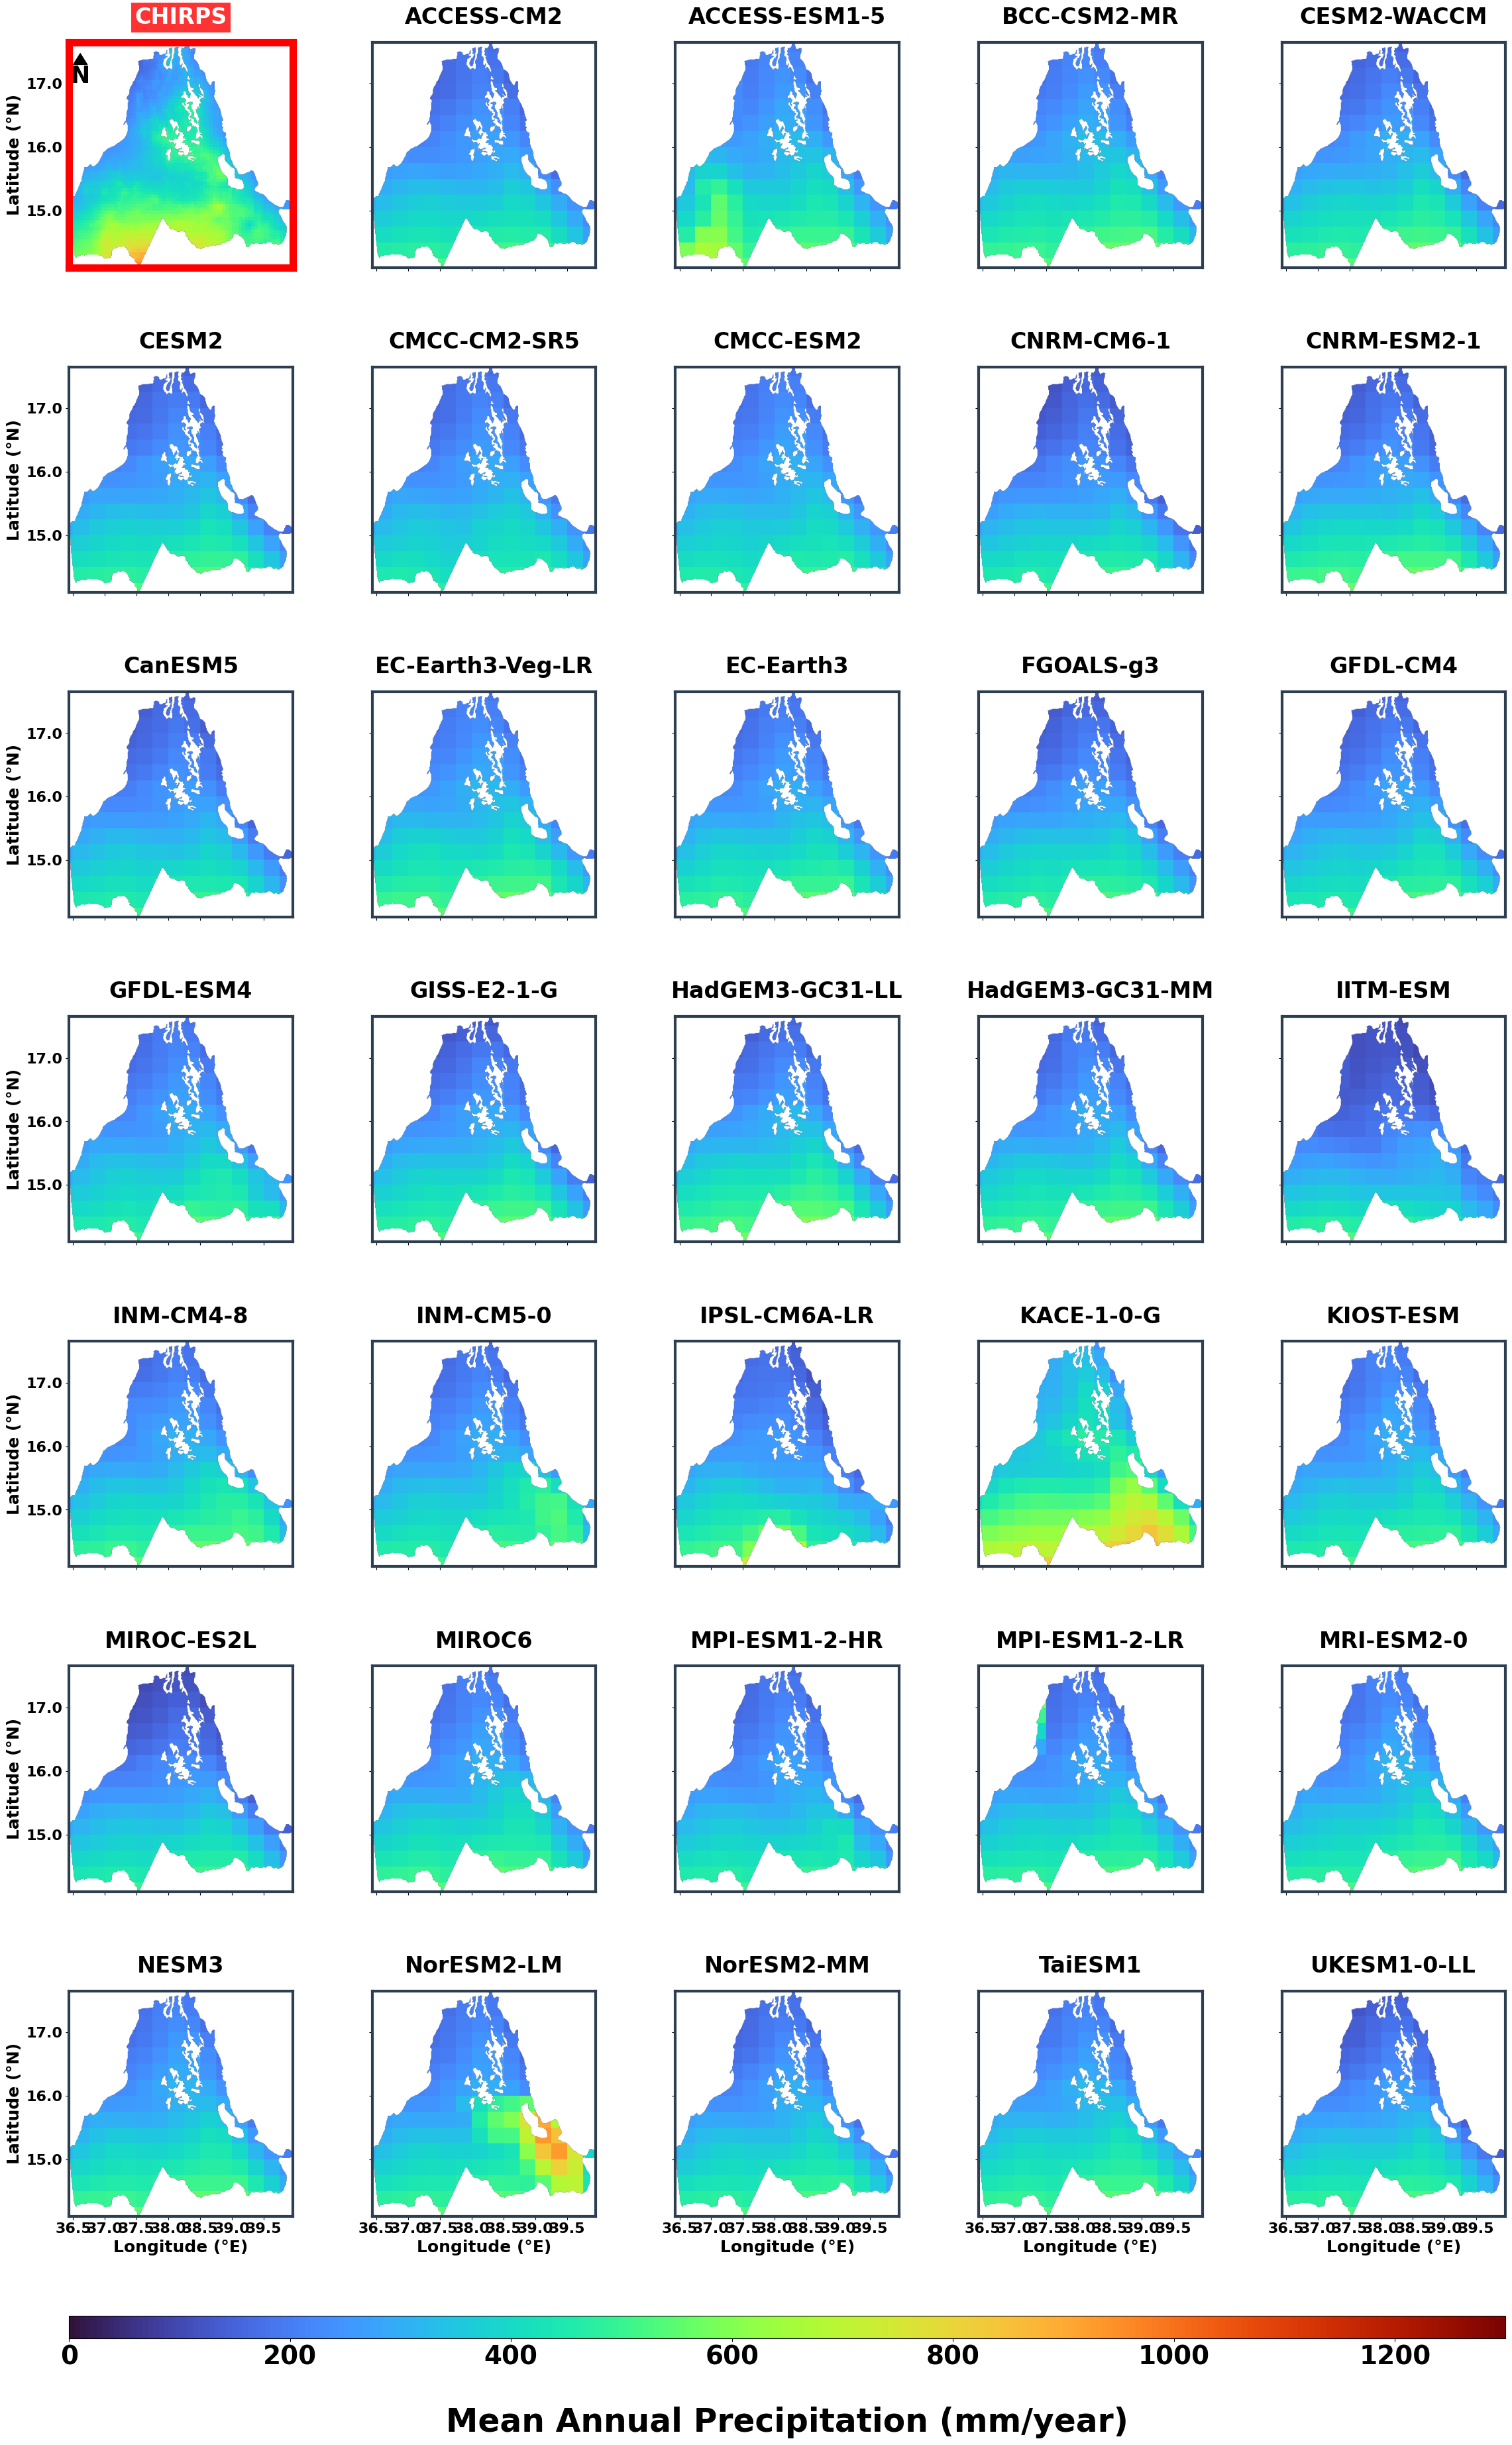

In [8]:
# =================================================================
# SCRIPT 7: SPATIAL MASTERPIECE - HISTORICAL RAINFALL MAPPING
# =================================================================

import os
import glob
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches

# 1. SETUP - Linking to GitHub data and output folders
map_folder = HIST_MAPS_DIR  # From Master Cell: geotiff/individual_models
roi_path = SHP_PATH         # From Master Cell: shp/SELECTED_ZONES_WGS1984.shp
output_folder = f"{OUTPUT_DIR}/NATIONAL_ANALYSIS_A"
output_fig = f"{output_folder}/CMIP6_Spatial_Masterpiece_600DPI.png"

# 2. LOAD ROI (Shapefile)
if not os.path.exists(roi_path):
    print(f"❌ Error: Shapefile not found at {roi_path}")
else:
    roi = gpd.read_file(roi_path)

    # 3. GATHER TIFF FILES
    tif_files = glob.glob(os.path.join(map_folder, '*.tif'))
    if not tif_files:
        print(f"❌ Error: No Geotiff files found in {map_folder}")
    else:
        # Sort logic: CHIRPS is the reference, so it goes first.
        chirps_file = [f for f in tif_files if "CHIRPS" in os.path.basename(f).upper()]
        model_files = sorted([f for f in tif_files if "CHIRPS" not in os.path.basename(f).upper()])
        final_files = chirps_file + model_files

        # 4. FIGURE CANVAS SETUP (35x45 inches for 35 panels)
        fig = plt.figure(figsize=(35, 45), facecolor='white')

        # Grid setup: 7 rows by 5 columns to fit 34 models + 1 CHIRPS
        grid = ImageGrid(fig, 111,
                         nrows_ncols=(7, 5),
                         axes_pad=(1.2, 1.5),
                         share_all=True,
                         cbar_location="bottom",
                         cbar_mode="single",
                         cbar_size="2%",
                         cbar_pad=1.5)

        print("🎨 Rendering the Spatial Masterpiece... this may take a moment.")

        # 5. EXECUTION LOOP
        for i, (ax, tif_path) in enumerate(zip(grid, final_files)):
            with rasterio.open(tif_path) as src:
                # Masking to Eritrea's specific study area boundaries
                out_image, out_transform = mask(src, roi.geometry, crop=True)
                out_image = out_image[0]

                # Data cleaning: handle nodata and zero values for sharp visualization
                out_image = np.where((out_image == src.nodata) | (out_image <= 0), np.nan, out_image)

                model_name = os.path.basename(tif_path).replace('_Mean_Annual_Rainfall.tif', '').replace('.tif', '')

                # The Plot: Using 'turbo' for high dynamic range across the 0-1300mm scale
                im = ax.imshow(out_image, cmap='turbo', vmin=0, vmax=1300,
                               extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

                # HIGHLIGHT CHIRPS: Red box for the reference model
                is_chirps = "CHIRPS" in model_name.upper()
                bbox_style = dict(facecolor='red', edgecolor='none', alpha=0.8) if is_chirps else None
                title_color = 'white' if is_chirps else 'black'

                ax.set_title(f"{model_name}", fontsize=24, fontweight='bold',
                             pad=20, bbox=bbox_style, color=title_color)

                # PERIPHERY COORDINATES (Clean look: only show on left and bottom edges)
                if i % 5 == 0:
                    ax.set_ylabel('Latitude (°N)', fontsize=18, fontweight='bold')
                    ax.tick_params(axis='y', labelsize=16, labelleft=True)
                if i >= 30:
                    ax.set_xlabel('Longitude (°E)', fontsize=18, fontweight='bold')
                    ax.tick_params(axis='x', labelsize=16, labelbottom=True)

                # TICKS FORMATTING
                ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                    label.set_fontweight('bold')

                # FRAME DESIGN: Bold Red frame for CHIRPS, Slate for CMIP6 models
                spine_color = 'red' if is_chirps else '#2C3E50'
                spine_width = 8 if is_chirps else 3
                for spine in ax.spines.values():
                    spine.set_edgecolor(spine_color)
                    spine.set_linewidth(spine_width)

                # NORTH ARROW (Only on the CHIRPS panel)
                if i == 0:
                    x, y, arrow_length = 0.05, 0.95, 0.1
                    ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
                                arrowprops=dict(facecolor='black', width=5, headwidth=15),
                                ha='center', va='center', fontsize=25, fontweight='bold',
                                xycoords='axes fraction')

        # 6. MASTER COLORBAR (Shared across all 35 maps)
        cb = grid.cbar_axes[0].colorbar(im)
        cb.set_label('Mean Annual Precipitation (mm/year)', fontsize=35, fontweight='bold', labelpad=40)
        cb.ax.tick_params(labelsize=28)
        for t in cb.ax.get_yticklabels():
            t.set_weight('bold')

        # SAVE AND CLOSE
        plt.savefig(output_fig, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"✅ Masterpiece successfully saved as: {output_fig}")
        plt.show()

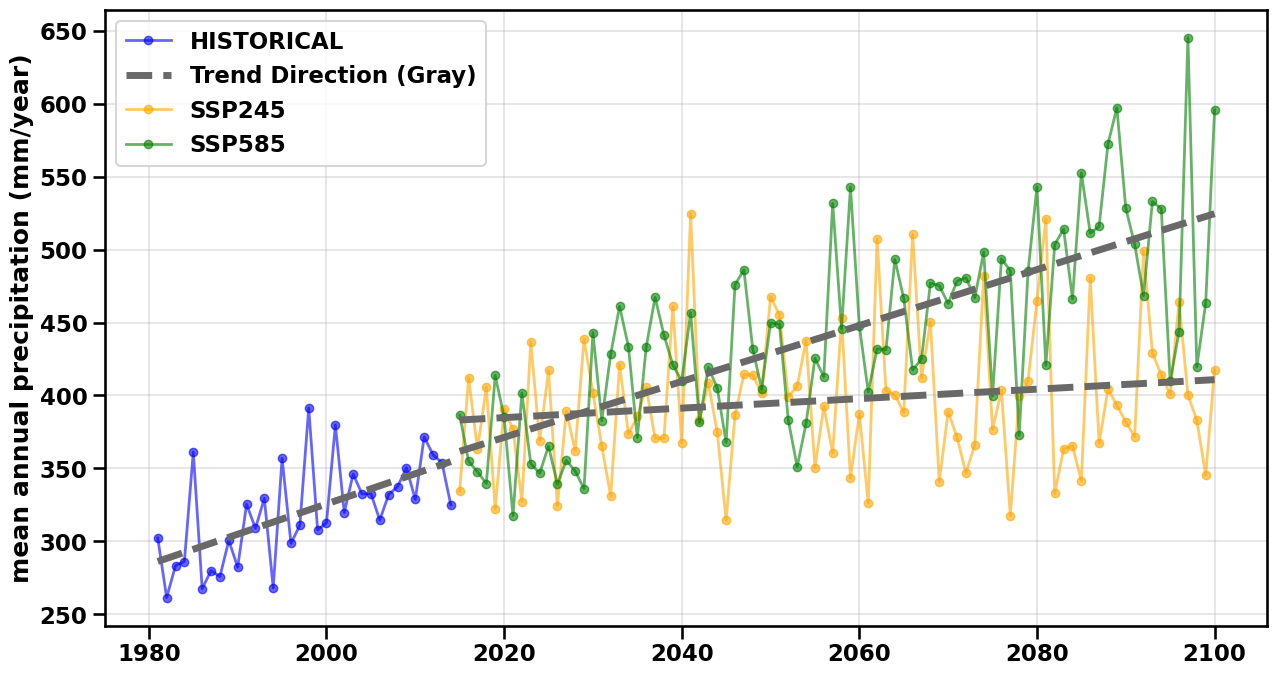

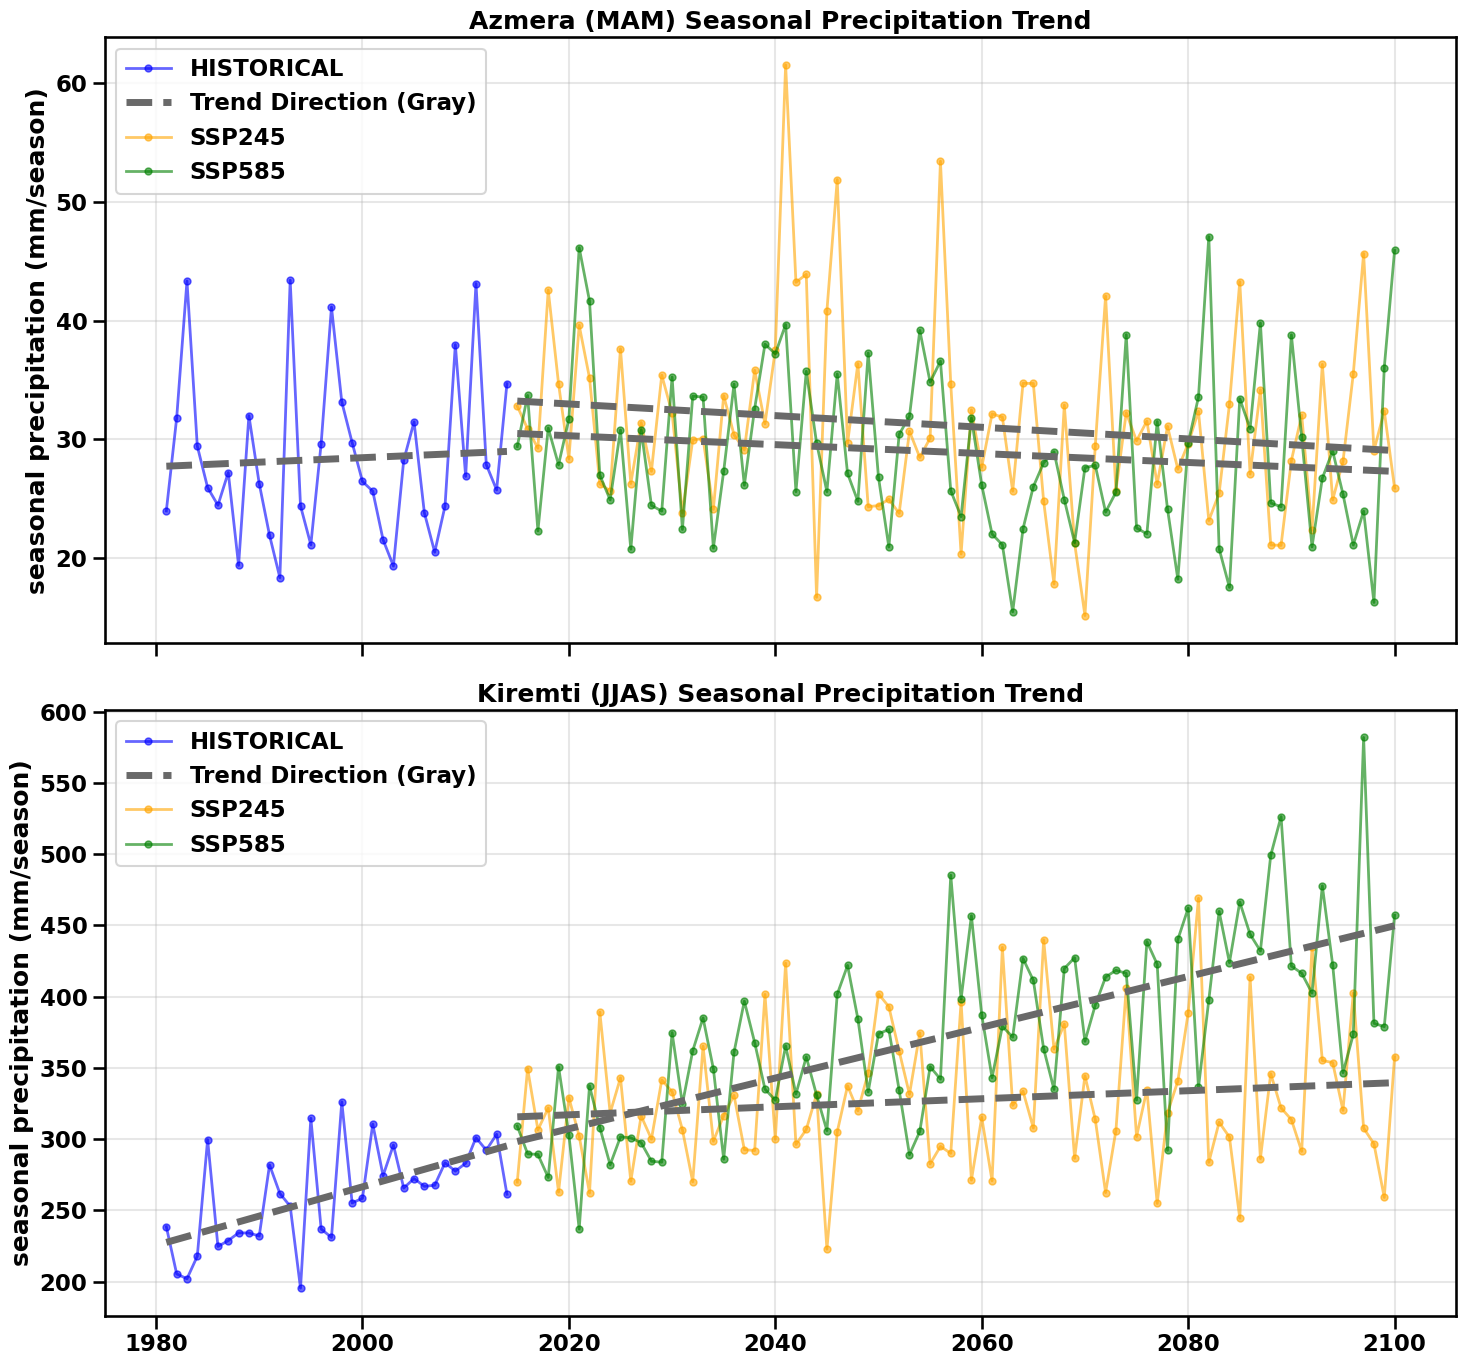

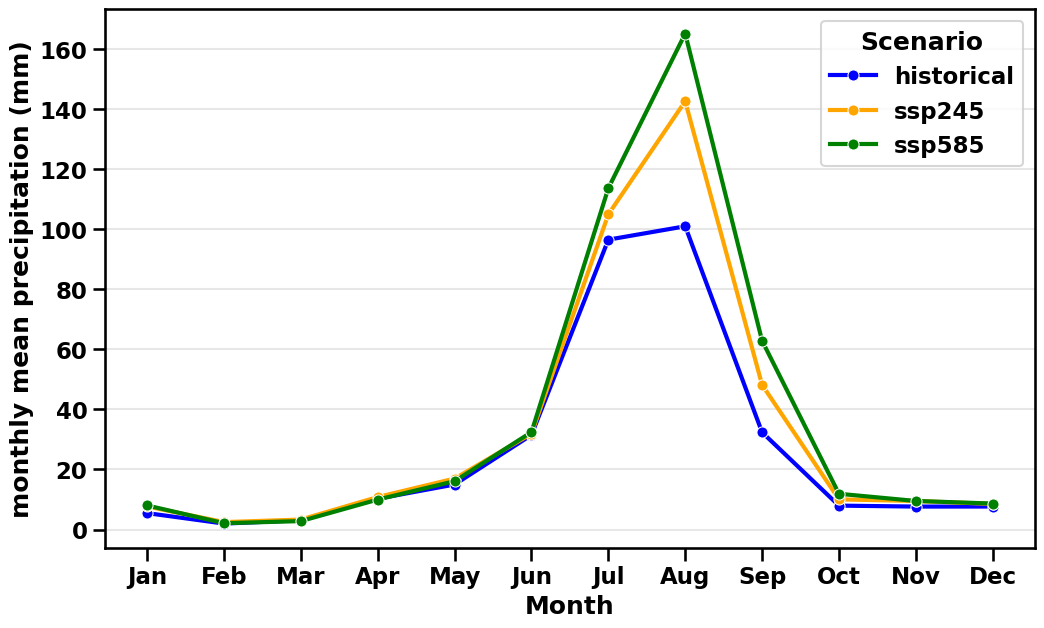

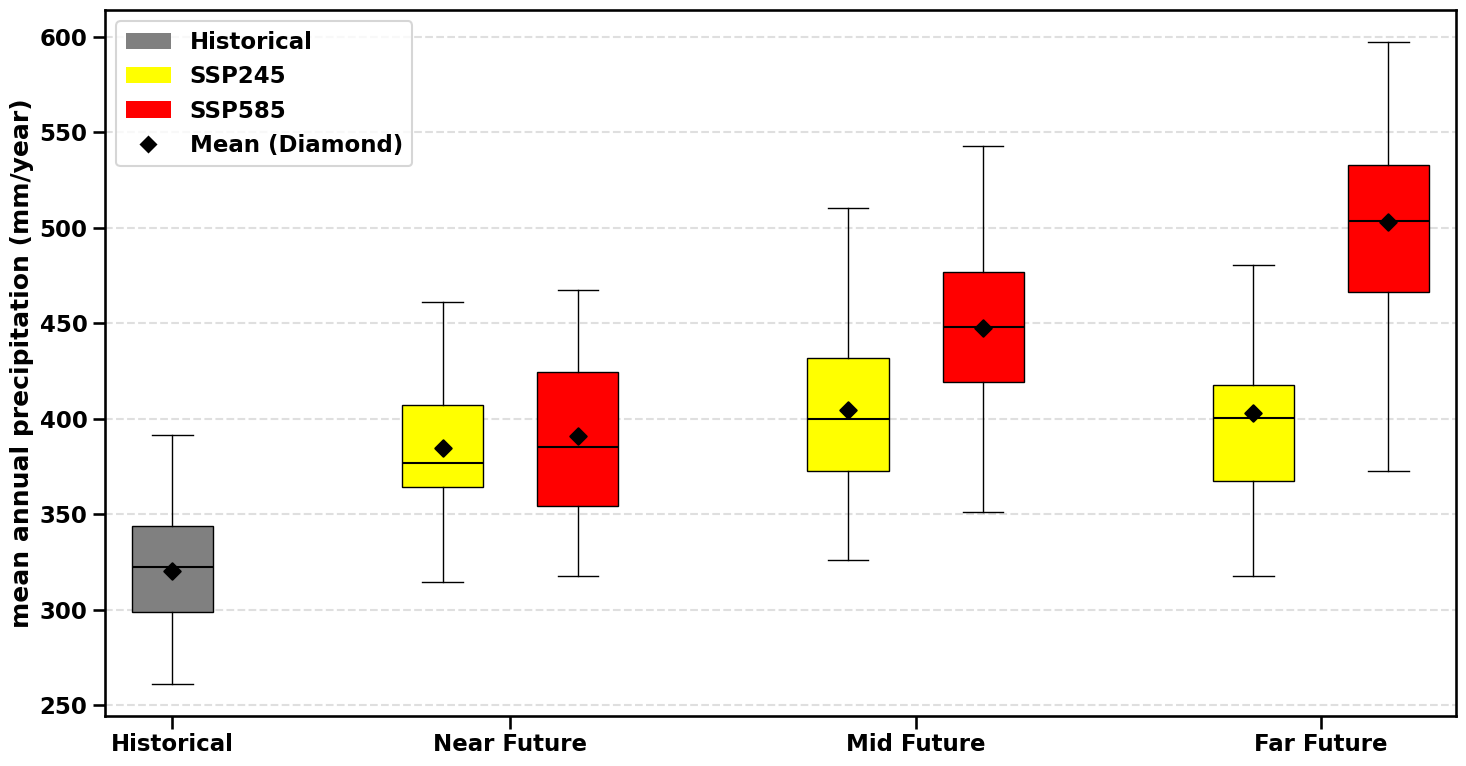

In [21]:
# =================================================================
# SCRIPT 8: MULTI-SCENARIO TREND & CLIMATOLOGY ANALYSIS (1981-2100)
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.patches import Patch
import os

# 1. LOAD AND MERGE - Using the paths defined in our Master First Page
# -----------------------------------------------------------------
hist_df = pd.read_csv(TOP_HIST)
ssp245_df = pd.read_csv(TOP_SSP245)
ssp585_df = pd.read_csv(TOP_SSP585)

# Ensure the output directory exists
final_output_dir = f"{OUTPUT_DIR}/TIME_SERIES"
if not os.path.exists(final_output_dir):
    os.makedirs(final_output_dir)

df = pd.concat([hist_df, ssp245_df, ssp585_df], ignore_index=True)

# 2. Statistical Prep
ens_mean = df.groupby(['Scenario', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

def get_eritrea_season(m):
    if m in [3, 4, 5]: return 'Azmera (MAM)'
    if m in [6, 7, 8, 9]: return 'Kiremti (JJAS)'
    return 'Dry'

def assign_slice(y):
    if 1981 <= y <= 2014: return 'Historical'
    if 2015 <= y <= 2045: return 'Near Future'
    if 2046 <= y <= 2075: return 'Mid Future'
    if 2076 <= y <= 2100: return 'Far Future'
    return None

ens_mean['Season'] = ens_mean['Month'].apply(get_eritrea_season)
ens_mean['TimeSlice'] = ens_mean['Year'].apply(assign_slice)

# Formatting
sns.set_context("talk")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
scenario_palette = {'historical': 'blue', 'ssp245': 'orange', 'ssp585': 'green'}

# Helper Function for Heavy Trendlines
def add_heavy_trendline(x, y, ax, label_needed=False):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    line = slope * x + intercept
    label = "Trend Direction (Gray)" if label_needed else ""
    ax.plot(x, line, color='#696969', linestyle='--', lw=5, alpha=1.0, label=label, zorder=10)

# =========================================================
# Plot 1: ANNUAL TOTAL (NO TITLE)
# =========================================================
annual = ens_mean.groupby(['Scenario', 'Year'])['Precip_mm'].sum().reset_index()
plt.figure(figsize=(15, 8))
first_trend = True
for scn, color in scenario_palette.items():
    subset = annual[annual['Scenario'] == scn]
    if not subset.empty:
        plt.plot(subset['Year'], subset['Precip_mm'], color=color, marker='o', markersize=6, lw=2, label=scn.upper(), alpha=0.6)
        add_heavy_trendline(subset['Year'], subset['Precip_mm'], plt.gca(), label_needed=first_trend)
        first_trend = False

plt.ylabel('mean annual precipitation (mm/year)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.savefig(f'{final_output_dir}/Eritrea_Annual_Final.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 2: SEASONAL TRENDS (WITH TITLE)
# =========================================================
seasonal = ens_mean[ens_mean['Season'] != 'Dry'].groupby(['Scenario', 'Year', 'Season'])['Precip_mm'].sum().reset_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)
for ax, seas in zip([ax1, ax2], ['Azmera (MAM)', 'Kiremti (JJAS)']):
    first_trend = True
    for scn, color in scenario_palette.items():
        subset = seasonal[(seasonal['Season'] == seas) & (seasonal['Scenario'] == scn)]
        if not subset.empty:
            ax.plot(subset['Year'], subset['Precip_mm'], color=color, marker='o', markersize=5, lw=2, label=scn.upper(), alpha=0.6)
            add_heavy_trendline(subset['Year'], subset['Precip_mm'], ax, label_needed=first_trend)
            first_trend = False
    ax.set_title(f'{seas} Seasonal Precipitation Trend', fontweight='bold', fontsize=18)
    ax.set_ylabel('seasonal precipitation (mm/season)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{final_output_dir}/Eritrea_Seasonal_Final.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 3: MONTHLY CLIMATOLOGY (NO TITLE)
# =========================================================
climatology = ens_mean.groupby(['Scenario', 'Month'])['Precip_mm'].mean().reset_index()
plt.figure(figsize=(12, 7))
sns.lineplot(data=climatology, x='Month', y='Precip_mm', hue='Scenario', marker='o', markersize=8, lw=3, palette=scenario_palette)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('monthly mean precipitation (mm)')
plt.grid(True, axis='y', alpha=0.3)
plt.savefig(f'{final_output_dir}/Eritrea_Monthly_Climatology.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 4: BOXPLOT (NO TITLE + MANUAL SPACING)
# =========================================================
boxplot_data_agg = ens_mean.groupby(['Scenario', 'Year', 'TimeSlice'])['Precip_mm'].sum().reset_index()

time_slices = ['Historical', 'Near Future', 'Mid Future', 'Far Future']
box_data, positions, colors, mean_values, mean_positions = [], [], [], [], []
pos_counter = 1

for ts in time_slices:
    scenarios_to_plot = ['historical', 'ssp245', 'ssp585']
    for sc in scenarios_to_plot:
        subset = boxplot_data_agg[(boxplot_data_agg['TimeSlice']==ts) & (boxplot_data_agg['Scenario']==sc)]['Precip_mm'].values
        if len(subset) > 0:
            box_data.append(subset)
            positions.append(pos_counter)
            if sc == 'historical': colors.append('gray')
            elif sc == 'ssp245': colors.append('yellow')
            else: colors.append('red')
            mean_values.append(np.mean(subset))
            mean_positions.append(pos_counter)
            pos_counter += 1
    pos_counter += 1

plt.figure(figsize=(15, 8))
bp = plt.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                  showfliers=False, medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.scatter(mean_positions, mean_values, marker='D', s=70, color='black', zorder=5)

new_xticks = []
for i, ts in enumerate(time_slices):
    group_pos = [p for p, d in zip(positions, box_data) if ts in boxplot_data_agg[boxplot_data_agg['Precip_mm'].isin(d)]['TimeSlice'].values]
    if group_pos: new_xticks.append(np.mean(group_pos))

plt.xticks(new_xticks, time_slices, fontweight='bold')
plt.ylabel("mean annual precipitation (mm/year)", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='gray', label='Historical'),
    Patch(facecolor='yellow', label='SSP245'),
    Patch(facecolor='red', label='SSP585'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='black', markersize=10, label='Mean (Diamond)')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(f'{final_output_dir}/Eritrea_Boxplot_Final.png', dpi=1200, bbox_inches='tight')
plt.show()

📡 Attempting to load Shapefile from: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/shp/SELECTED_ZONES_WGS1984.shp
✅ SUCCESS: Shapefile loaded. Proceeding to map generation...
✅ Masterpiece saved: /content/NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections/outputs/Top10_Ensemble_Masterpiece_1200DPI.png


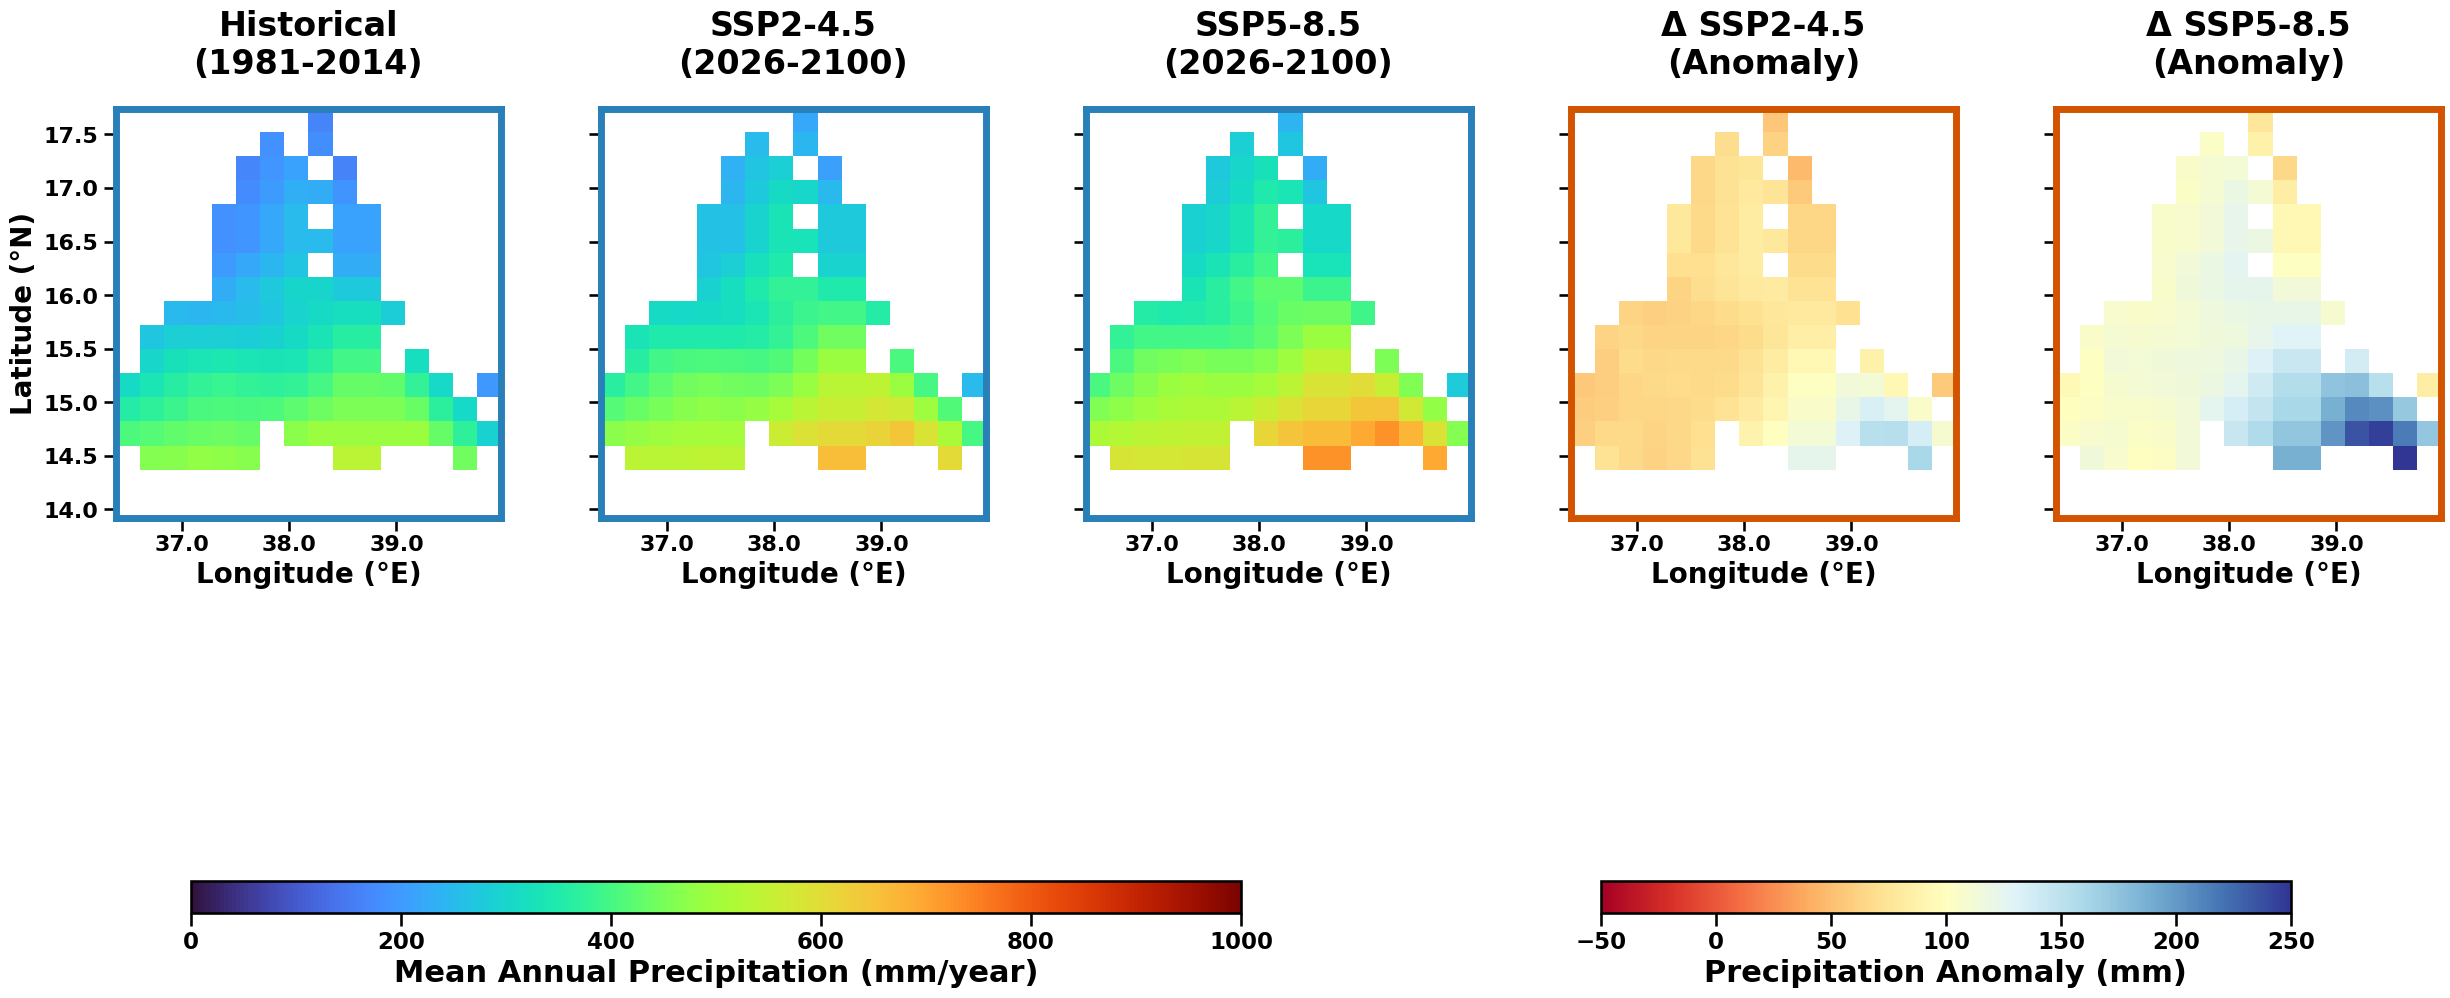

In [23]:
# =================================================================
# SCRIPT 9: THE ENSEMBLE MASTERPIECE (FORCED GITHUB PATH)
# =================================================================

import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# 1. SETUP - Using the paths defined in our Master First Page
# -----------------------------------------------------------------

REPO_NAME = "NEX-GDDP-CMIP6-Eritrea-Rainfall-Projections"
map_folder = f"/content/{REPO_NAME}/geotiff/ensembles"
roi_path = f"/content/{REPO_NAME}/shp/SELECTED_ZONES_WGS1984.shp"
output_folder = f"/content/{REPO_NAME}/outputs"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

output_fig = f"{output_folder}/Top10_Ensemble_Masterpiece_1200DPI.png"

# 2. LOAD ROI (Shapefile)
# -----------------------------------------------------------------
print(f"📡 Attempting to load Shapefile from: {roi_path}")

if not os.path.exists(roi_path):
    print(f"❌ STILL NOT FOUND at: {roi_path}")
    print("👉 ACTION: Look at your Colab sidebar. If the folder name is different than")
    print(f"'{REPO_NAME}', please rename the REPO_NAME variable in line 16.")
else:
    roi = gpd.read_file(roi_path)
    print(f"✅ SUCCESS: Shapefile loaded. Proceeding to map generation...")

    # 3. SCIENTIFIC FILE ORDERING
    # -----------------------------------------------------------------
    file_order = [
        'Top10_Hist_1981_2014_NEW.tif',
        'Top10_SSP245_Full_NEW.tif',
        'Top10_SSP585_Full_NEW.tif',
        'Top10_Change_SSP245_NEW.tif',
        'Top10_Change_SSP585_NEW.tif'
    ]

    # 4. FIGURE CANVAS SETUP
    # -----------------------------------------------------------------
    fig = plt.figure(figsize=(30, 16), facecolor='white')
    grid = ImageGrid(fig, 111,
                     nrows_ncols=(1, 5),
                     axes_pad=1.0,
                     share_all=True,
                     cbar_mode=None)

    for i, (ax, filename) in enumerate(zip(grid, file_order)):
        tif_path = os.path.join(map_folder, filename)

        if not os.path.exists(tif_path):
            print(f"⚠️ Warning: {filename} not found in {map_folder}")
            continue

        with rasterio.open(tif_path) as src:
            out_image, _ = mask(src, roi.geometry, crop=True)
            out_image = out_image[0]
            out_image = np.where((out_image == src.nodata) | (out_image <= -999) | (out_image == 0), np.nan, out_image)

            name_map = {
                'Top10_Hist_1981_2014_NEW.tif': 'Historical\n(1981-2014)',
                'Top10_SSP245_Full_NEW.tif': 'SSP2-4.5\n(2026-2100)',
                'Top10_SSP585_Full_NEW.tif': 'SSP5-8.5\n(2026-2100)',
                'Top10_Change_SSP245_NEW.tif': 'Δ SSP2-4.5\n(Anomaly)',
                'Top10_Change_SSP585_NEW.tif': 'Δ SSP5-8.5\n(Anomaly)'
            }
            display_title = name_map.get(filename, "Ensemble")
            cmap, vmin, vmax = ('RdYlBu', -50, 250) if "Change" in filename else ('turbo', 0, 1000)

            im = ax.imshow(out_image, cmap=cmap, vmin=vmin, vmax=vmax,
                           extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

            ax.set_title(display_title, fontsize=24, fontweight='bold', pad=25)

            if i == 0:
                ax.set_ylabel('Latitude (°N)', fontsize=20, fontweight='bold')
                ax.tick_params(axis='y', labelsize=16, labelleft=True)
            else:
                ax.tick_params(axis='y', labelleft=False)

            ax.set_xlabel('Longitude (°E)', fontsize=20, fontweight='bold')
            ax.tick_params(axis='x', labelsize=16, labelbottom=True)
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

            spine_color = '#d35400' if "Change" in filename else '#2980b9'
            for spine in ax.spines.values():
                spine.set_edgecolor(spine_color)
                spine.set_linewidth(5)

    # 5. DUAL COLORBARS
    # -----------------------------------------------------------------
    cax1 = fig.add_axes([0.15, 0.12, 0.35, 0.02])
    cb1 = fig.colorbar(grid[0].get_images()[0], cax=cax1, orientation='horizontal')
    cb1.set_label('Mean Annual Precipitation (mm/year)', fontsize=22, fontweight='bold')

    cax2 = fig.add_axes([0.62, 0.12, 0.23, 0.02])
    cb2 = fig.colorbar(grid[4].get_images()[0], cax=cax2, orientation='horizontal')
    cb2.set_label('Precipitation Anomaly (mm)', fontsize=22, fontweight='bold')

    plt.savefig(output_fig, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"✅ Masterpiece saved: {output_fig}")
    plt.show()

🚀 Processing Ensemble Data from GitHub...


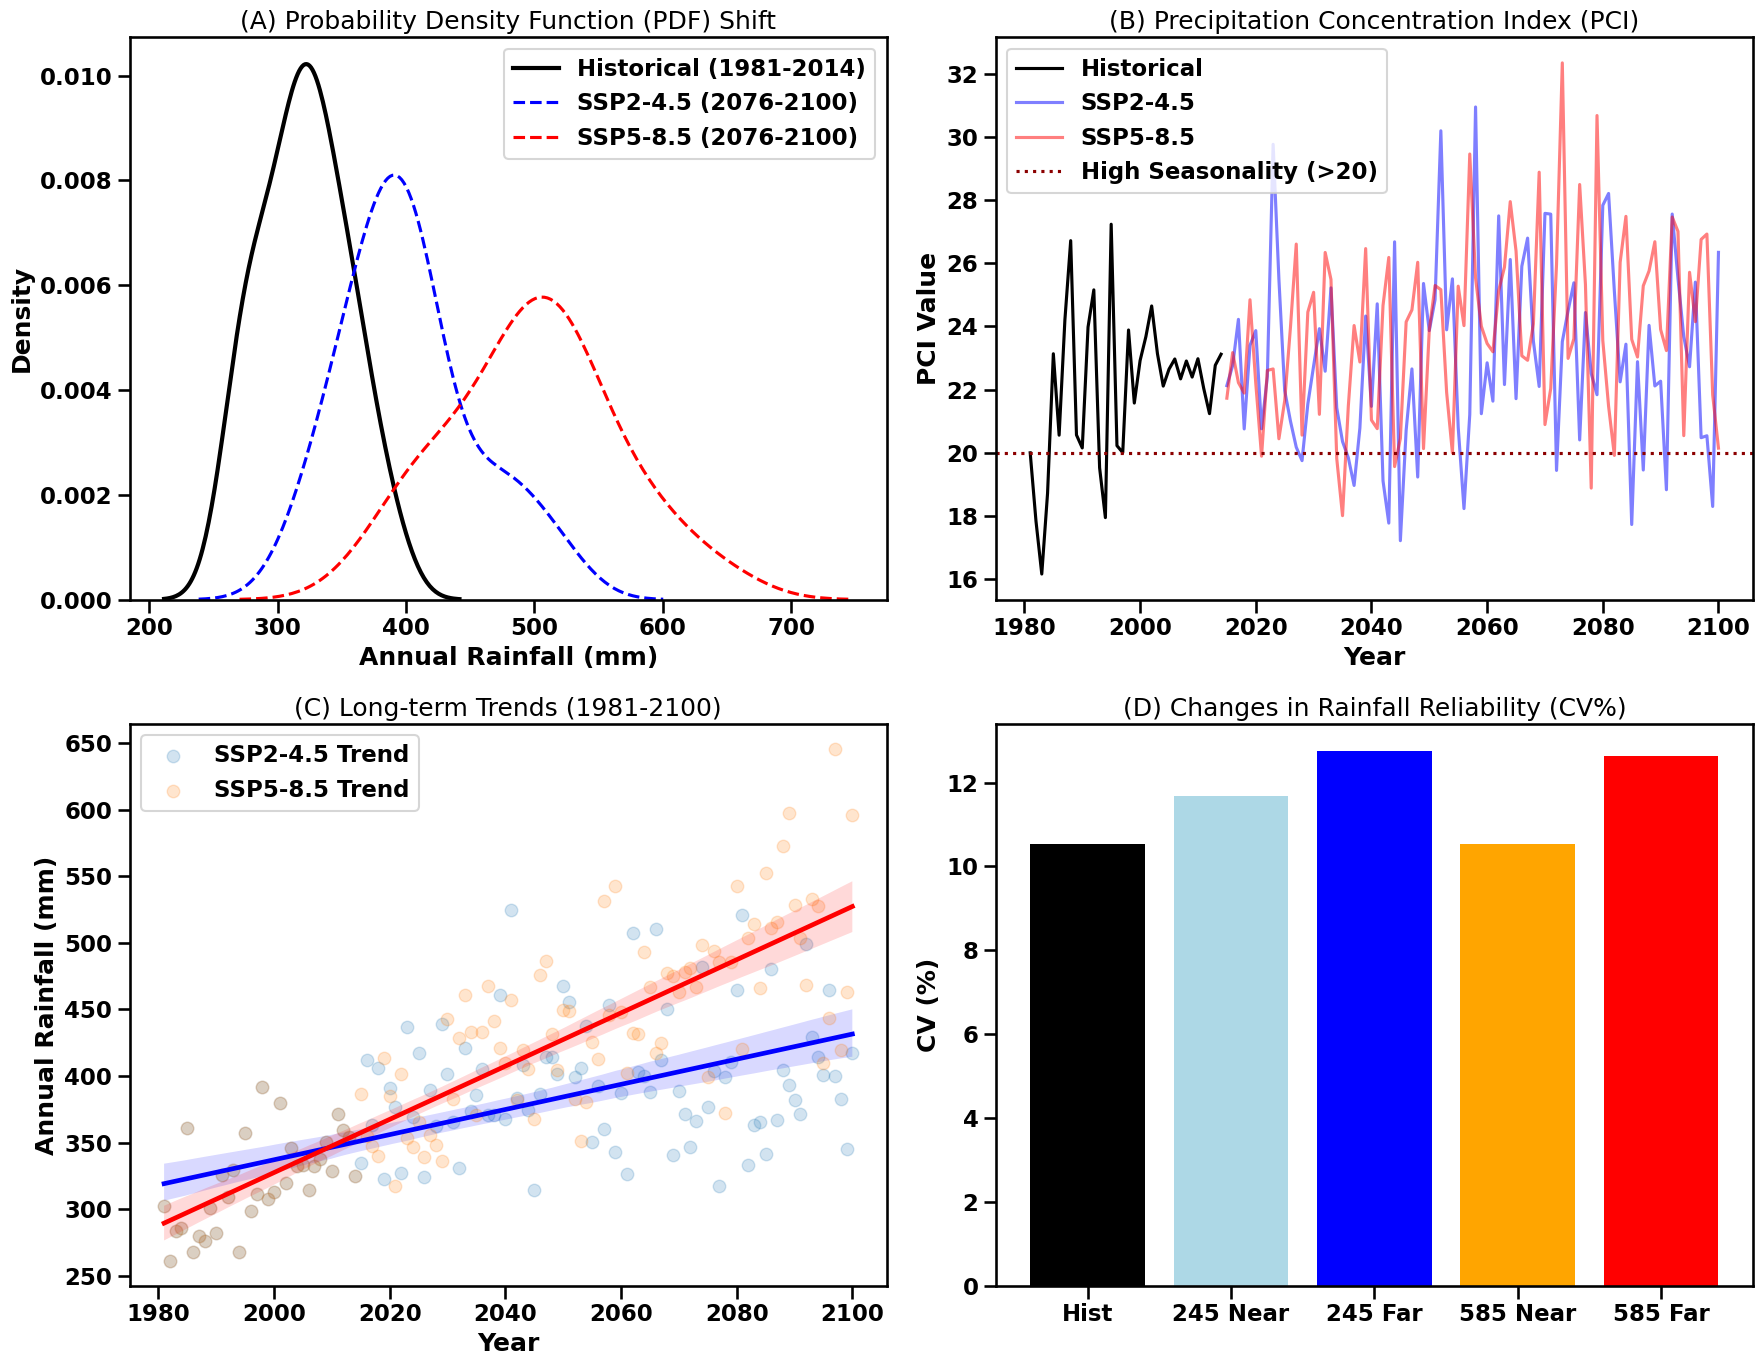

✅ Statistical Analysis Masterpiece saved to: /content/FINAL_OUTPUTS/ADVANCED_ANALYSIS


In [24]:
# =================================================================
# SCRIPT 10: ADVANCED VALIDATION - PDF SHIFTS, PCI, AND RELIABILITY
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. SETUP PATHS - Using the paths defined in our Master First Page
# -----------------------------------------------------------------
paths = {
    'Historical': TOP_HIST,
    'SSP245': TOP_SSP245,
    'SSP585': TOP_SSP585
}

# Using OUTPUT_DIR
output_folder = f"{OUTPUT_DIR}/ADVANCED_ANALYSIS"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. DATA PROCESSING ENGINE
# -----------------------------------------------------------------
def get_mme_data(path):
    df = pd.read_csv(path)
    m_mean = df.groupby(['Year', 'Month'])['Precip_mm'].mean().reset_index()
    a_total = m_mean.groupby('Year')['Precip_mm'].sum().reset_index()
    return m_mean, a_total

print("🚀 Processing Ensemble Data from GitHub...")
hist_m, hist_a = get_mme_data(paths['Historical'])
s245_m, s245_a = get_mme_data(paths['SSP245'])
s585_m, s585_a = get_mme_data(paths['SSP585'])

# Helpers
full_245 = pd.concat([hist_a, s245_a])
full_585 = pd.concat([hist_a, s585_a])

def get_cv(series):
    return (series.std() / series.mean()) * 100

def calc_pci(df_m):
    pci_list = []
    for yr in df_m['Year'].unique():
        p = df_m[df_m['Year'] == yr]['Precip_mm'].values
        if len(p) == 12:
            pci = (np.sum(p**2) / (np.sum(p)**2)) * 100
            pci_list.append({'Year': yr, 'PCI': pci})
    return pd.DataFrame(pci_list)

pci_h = calc_pci(hist_m); pci_245 = calc_pci(s245_m); pci_585 = calc_pci(s585_m)

# 3. CREATE 4-PANEL FIGURE (Your Original Design)
# -----------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
sns.set_context("talk")

# PANEL A: PDF SHIFT (Top Left)
ax0 = axes[0, 0]
sns.kdeplot(hist_a['Precip_mm'], label='Historical (1981-2014)', color='black', lw=3, ax=ax0)
sns.kdeplot(s245_a.query('Year>=2075')['Precip_mm'], label='SSP2-4.5 (2076-2100)', color='blue', ls='--', ax=ax0)
sns.kdeplot(s585_a.query('Year>=2075')['Precip_mm'], label='SSP5-8.5 (2076-2100)', color='red', ls='--', ax=ax0)
ax0.set_title('(A) Probability Density Function (PDF) Shift')
ax0.set_xlabel('Annual Rainfall (mm)'); ax0.set_ylabel('Density'); ax0.legend()

# PANEL B: PCI TREND (Top Right)
ax1 = axes[0, 1]
ax1.plot(pci_h['Year'], pci_h['PCI'], color='black', label='Historical')
ax1.plot(pci_245['Year'], pci_245['PCI'], color='blue', alpha=0.5, label='SSP2-4.5')
ax1.plot(pci_585['Year'], pci_585['PCI'], color='red', alpha=0.5, label='SSP5-8.5')
ax1.axhline(y=20, color='darkred', linestyle=':', label='High Seasonality (>20)')
ax1.set_title('(B) Precipitation Concentration Index (PCI)')
ax1.set_xlabel('Year'); ax1.set_ylabel('PCI Value'); ax1.legend()

# PANEL C: TREND REGRESSION (Bottom Left)
ax2 = axes[1, 0]
sns.regplot(data=full_245, x='Year', y='Precip_mm', scatter_kws={'alpha':0.2}, line_kws={'color':'blue'}, label='SSP2-4.5 Trend', ax=ax2)
sns.regplot(data=full_585, x='Year', y='Precip_mm', scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, label='SSP5-8.5 Trend', ax=ax2)
ax2.set_title('(C) Long-term Trends (1981-2100)')
ax2.set_xlabel('Year'); ax2.set_ylabel('Annual Rainfall (mm)'); ax2.legend()

# PANEL D: CV BAR CHART (Bottom Right)
ax3 = axes[1, 1]
cv_vals = [
    get_cv(hist_a['Precip_mm']),
    get_cv(s245_a.query('2026<=Year<=2050')['Precip_mm']),
    get_cv(s245_a.query('2076<=Year<=2100')['Precip_mm']),
    get_cv(s585_a.query('2026<=Year<=2050')['Precip_mm']),
    get_cv(s585_a.query('2076<=Year<=2100')['Precip_mm'])
]
labels = ['Hist', '245 Near', '245 Far', '585 Near', '585 Far']
ax3.bar(labels, cv_vals, color=['black', 'lightblue', 'blue', 'orange', 'red'])
ax3.set_title('(D) Changes in Rainfall Reliability (CV%)')
ax3.set_ylabel('CV (%)')

plt.tight_layout()
plt.savefig(f'{output_folder}/Figure_Panel_Final.png', dpi=300)
plt.show()

print(f"✅ Statistical Analysis Masterpiece saved to: {output_folder}")